## **Problem Statement**

### Business Context

Northbridge Bank is a mid-to-large commercial bank whose core business is providing loans and credit facilities to businesses, generating revenue primarily through interest income and related lending fees while managing the associated credit risk. It has a $6–18 billion lending portfolio covering approximately 2,000–8,000 borrower accounts across 8–12 industry sectors. Its Credit Risk Analytics team supports the CRO, Board Risk Management Committee, Credit Committee, internal audit, and regulatory teams, handling 15–20 ad-hoc portfolio data requests per day in addition to scheduled reporting.
Most requests are routine questions such as sector-wise exposure, overdue accounts above a threshold, or top borrowers by outstanding amount. Although analysts already know the required tables, joins, and business rules, each request takes 2–4 hours because they must manually interpret the question, write and execute SQL, validate results, format the output, and respond. Around 60–70% are repetitive variations of previously answered questions.

This repetitive workload reduces the team's capacity for higher-value activities such as model validation, stress testing, portfolio strategy, and emerging-risk identification. The bank therefore wants business users to obtain routine portfolio answers directly, while ensuring accuracy, transparent logic, auditability, and human escalation for complex or ambiguous questions.

The solution must operate within the bank's existing environment. Of 10 analysts, six are proficient in SQL and only two routinely handle complex joins and credit-risk calculations. Business users do not understand SQL, while analysts must retain control over complex requests. Credit-risk data is stored in a controlled analytical database, and the solution must operate in read-only mode. Customer-identifiable information must not be exposed through unrestricted or public LLM services; approved enterprise-grade LLM APIs may be used subject to the bank’s security and data-governance requirements. All AI-generated outputs must remain reviewable and auditable.

Previous approaches - a shared SQL library, BI dashboards, and Excel templates - addressed parts of the problem but had limitations. The SQL library became unreliable after schema changes, dashboards supported only predefined questions and required BI development for new requests, and Excel templates created dependency on individual analysts. None provided a unified solution for recurring queries, ad-hoc questions, and auditability.


### Objective

Build an internal natural-language query engine that enables business users to ask routine commercial lending portfolio questions in plain English and receive verified answers in minutes, while allowing analysts to focus on complex, judgment-intensive work.

The system will:

- Use pre-approved SQL templates for recurring queries that are tested, version-controlled, and updated when schemas change.
- Generate SQL for uncovered questions, restricted to read-only SELECT queries.
- Validate generated SQL for correctness and retry once if validation fails before escalating to a human analyst.
- Display the SQL query used, raw data returned, and a confidence score with every answer.
- Maintain a complete audit trail for every analytical output.

The initiative is prioritized this quarter due to increasing demand for faster risk reporting, fixed specialist headcount, and regulatory and governance requirements for timely, reproducible, and auditable portfolio-risk answers. Continuing the manual model would increase workload, deepen dependency on specialists, and delay responses during time-sensitive risk or regulatory events.


**Target Outcomes - Within One Quarter**

- Recurring query turnaround: under 2 minutes.
- Ad-hoc query turnaround: under 5 minutes for queries that do not require human review.
- Maintain a complete audit trail for every system-generated analytical output.

**PoC Scope**

The PoC covers only the commercial lending portfolio and read-only analytical queries. It will not perform database updates or write operations and will not replace human judgment for complex credit-risk decisions.


### Data Description



The dataset consists of four database tables supporting commercial lending and credit-risk analysis, along with a test-case CSV used to evaluate the query engine.

- The database supports analysis of a commercial lending portfolio, including sector exposure, delinquency, restructuring, interest-rate analysis, credit ratings, and IFRS 9 provisioning.

- The `test_queries.csv` file provides the ground-truth cases used to evaluate whether the query engine selects the appropriate route and verified query where applicable, and produces the expected analytical output.

#### credit_risk_portfolio.db

**sector_master**: Reference table for industry sector classification

* **sector_code**: Internal sector code (for example, SEC_RE, SEC_INFRA)
* **sector_name**: Human-readable sector name
* **naics_code**: North American Industry Classification System code
* **naics_description**: Description of the NAICS classification
* **is_sensitive_sector**: Flag indicating regulatory-sensitive sectors

**loan_master**: Central loan-level table containing borrower, loan, financial, and delinquency information

* **loan_account_number**: Unique loan identifier
* **borrower_id, borrower_name, borrower_type, group_name, state**: Borrower attributes
* **product_type, loan_category, sector_code**: Loan classification
* **sanctioned_amount, disbursed_amount, outstanding_principal, outstanding_interest, total_outstanding**: Financial amounts
* **interest_rate, rate_type, sanction_date, maturity_date, repayment_frequency**: Loan terms
* **is_consortium, is_restructured, restructuring_date, is_secured**: Loan flags
* **days_past_due, asset_classification, classification_date**: Delinquency and asset-classification information

**borrower_rating**: Credit-rating history maintained for each borrower across assessment dates

* **borrower_id, rating_date**: Borrower and assessment identifiers
* **internal_rating, previous_rating, rating_direction**: Rating information and movement
* **external_rating_agency, external_rating**: External rating information
* **pd_estimate**: Probability of default estimate

**provisioning**: IFRS 9 staging and expected credit loss information by loan and reporting date

* **loan_account_number, reporting_date**: Loan and reporting-period identifiers
* **ifrs9_stage, stage_rationale**: IFRS 9 stage and rationale
* **pd_12_month, pd_lifetime, lgd_estimate, ead_amount, ecl_amount**: Provisioning and credit-risk metrics
* **provision_held, provision_coverage_ratio, is_individually_assessed**: Provision details


**Reporting Timeline & Metadata**

* **Provisioning Dates**: 2024-12-31, 2025-03-31, 2025-06-30, 2025-09-30 *(Latest: 2025-09-30)*
* **Rating Dates**: 2024-09-30, 2024-12-31, 2025-03-31, 2025-06-30, 2025-09-30 *(Latest: 2025-09-30)*
* **NPA Definition**: `asset_classification IN ('Substandard', 'Doubtful', 'Loss')`

#### test_queries.csv




Evaluation dataset containing predefined test cases and their expected outcomes

* **Test Case**: Unique identifier for each evaluation case
* **User Query**: Natural-language question submitted to the query engine
* **Expected Route**: Expected processing path - verified or generated
* **Expected Query ID**: Expected verified-query template where applicable
* **Expected Answer**: Expected result or answer characteristics used for evaluation


## **Please read the instructions carefully before starting the project.**

This is a Python Notebook file with blocks of code pre-filled in alignment with a possible solution for the business use case at hand, and some blank sections where the code has to be written from scratch.

* Please feel free to
    * leverage the pre-filled code blocks as they are, or
    * update the pre-filled code blocks to incorporate necessary changes as per your desired solution workflow for the business problem at hand, or
    * discard the pre-filled code blocks and write the entire code from scratch
* Notebook sections and code blocks that contain instructions and tasks to be performed are mentioned.
* Blanks '\_\_\_\_\_' are provided in the notebook that need to be filled with an appropriate code to get the correct result.
    * With every '\_\_\_\_\_' blank, there is a comment that briefly describes what needs to be filled in the blank space.
* Identify the task to be performed correctly, and only then proceed to write the required code.
* Please sequentially run the code cells from the beginning to avoid any unnecessary errors.
* Add the results/observations derived from the analysis under the respective notebook sections as per the grading rubric requirements.

## **Installing and Importing Necessary Libraries and Dependencies**

In [209]:
!pip install -q langchain langchain-core langchain-openai pandas numpy sqlparse

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for VSCode/Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [210]:
# write the code to import all necessary libraries

from typing import TypedDict, List, Any, Dict, Optional  # Type hints and structured data types
import pandas as pd  # Data manipulation and analysis
import sqlite3  # Connect to and query the SQLite database
import sqlparse  # Parse and format SQL queries
import json  # Read and write JSON data
import re  # Perform regular expression-based text processing
import os  # Interact with the operating system and environment variables


from langchain_openai import ChatOpenAI  # Use OpenAI chat models through LangChain
from langchain_core.prompts import ChatPromptTemplate  # Create reusable structured prompts
from langchain_core.messages import HumanMessage, SystemMessage  # Define system and user messages for LLM calls

import warnings  # Manage Python warning messages
warnings.filterwarnings('ignore')  # Suppress warning messages to keep notebook output clean

## **Data Loading and Model Initialization**



### OpenAI API Calling

We load OpenAI credentials from a secure config.json file and store them as environment variables.



In [211]:
# Load the JSON file and extract values
file_name = 'config.json'                                                       # Name of the configuration file
with open(file_name, 'r') as file:                                              # Open the config file in read mode
    config = json.load(file)                                                    # Load the JSON content as a dictionary
    OPENAI_API_KEY = config.get("OPENAI_API_KEY")                               # Extract the API key from the config
    OPENAI_API_BASE = config.get("OPENAI_API_BASE")                             # Extract the OpenAI base URL from the config

# Store API credentials in environment variables
os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY                                   # Set API key as environment variable
os.environ["OPENAI_BASE_URL"] = OPENAI_API_BASE                                 # Set API base URL as environment variable

In [212]:
# write the code to set up the LLM(s)

llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)
evaluator_llm = ChatOpenAI(model='gpt-4o', temperature=0)


### Database Loading

In [213]:
# Load and connect the database to sqlite database, and store the connection in the variable conn

db_path = '/content/credit_risk_portfolio.db'
conn = sqlite3.connect(f'file:{db_path}?mode=ro', uri=True)
print("Database connection established (read-only mode)")




Database connection established (read-only mode)


**Connect to the SQLite Database**

Create a **read-only connection** to the provided SQLite database using `sqlite3`. Use URI mode with `?mode=ro` to prevent any write operations.

**Sample code:**

```python
import sqlite3

conn = sqlite3.connect(f'file:{db_path}?mode=ro', uri=True)

print("Database connection established (read-only mode)")
```


In [214]:
# preview each table

tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)
tables

,name
0,borrower_rating
1,loan_master
2,provisioning
3,sector_master
4,sqlite_sequence


Define the database schema that will be provided to the LLM in the prompts.

In [215]:
database_schema = """
sector_master:
  sector_code (TEXT, PK): internal sector identifier (e.g., SEC_RE, SEC_INFRA)
  sector_name (TEXT): human-readable sector name (e.g., Real Estate, Infrastructure)
  naics_code (TEXT): NAICS industry classification code
  naics_description (TEXT): NAICS code description
  is_sensitive_sector (INTEGER): 1 if sensitive sector, 0 otherwise

loan_master:
  loan_account_number (TEXT, PK): unique loan identifier
  borrower_id (TEXT): borrower identifier (joins to borrower_rating.borrower_id)
  borrower_name (TEXT): registered legal name of the borrower
  borrower_type (TEXT): entity type (C-Corporation, S-Corporation, LLC, LP, Partnership, Sole Proprietorship)
  group_name (TEXT): business group affiliation, NULL if standalone
  state (TEXT): state of registered office
  product_type (TEXT): Term Loan, Working Capital, Cash Credit, Overdraft, Bill Discounting, Letter of Credit
  loan_category (TEXT): Corporate, Mid-Corporate, SME
  sector_code (TEXT, FK): joins to sector_master.sector_code
  sanctioned_amount (REAL): original approved loan amount in USD
  disbursed_amount (REAL): total amount disbursed in USD
  outstanding_principal (REAL): current principal outstanding in USD
  outstanding_interest (REAL): accrued interest outstanding in USD
  total_outstanding (REAL): outstanding_principal + outstanding_interest in USD
  interest_rate (REAL): current interest rate as percentage
  rate_type (TEXT): Fixed, Floating, MCLR-linked, Repo-linked
  sanction_date (DATE): date of original sanction
  maturity_date (DATE): contractual maturity date
  repayment_frequency (TEXT): Monthly, Quarterly, Bullet
  branch_code (TEXT): originating branch identifier
  branch_name (TEXT): originating branch name
  relationship_manager (TEXT): assigned relationship manager name
  is_consortium (INTEGER): 1 if consortium loan, 0 otherwise
  is_restructured (INTEGER): 1 if restructured, 0 otherwise
  restructuring_date (DATE): date of last restructuring, NULL if not restructured
  is_secured (INTEGER): 1 if secured, 0 if unsecured
  days_past_due (INTEGER): current maximum days past due for the loan
  asset_classification (TEXT): Pass, Special Mention, Substandard, Doubtful, Loss
  classification_date (DATE): date current classification was assigned

borrower_rating:
  rating_id (INTEGER, PK): auto-increment identifier
  borrower_id (TEXT, FK): joins to loan_master.borrower_id
  rating_date (DATE): date of rating assessment
  internal_rating (TEXT): bank's internal rating grade (AAA through D, 18-grade scale)
  previous_rating (TEXT): rating grade from prior assessment
  rating_direction (TEXT): Upgraded, Downgraded, Maintained
  external_rating_agency (TEXT): S&P, Moody's, Fitch, DBRS Morningstar, Kroll, or NULL
  external_rating (TEXT): external agency rating
  pd_estimate (REAL): probability of default (decimal, e.g., 0.02 for 2%)
  rating_model_version (TEXT): internal rating model version

provisioning:
  provision_id (INTEGER, PK): auto-increment identifier
  loan_account_number (TEXT, FK): joins to loan_master.loan_account_number
  reporting_date (DATE): quarter-end reporting date
  ifrs9_stage (INTEGER): IFRS 9 stage (1, 2, or 3)
  stage_rationale (TEXT): reason for stage assignment
  pd_12_month (REAL): 12-month probability of default
  pd_lifetime (REAL): lifetime probability of default
  lgd_estimate (REAL): loss given default (decimal)
  ead_amount (REAL): exposure at default in USD
  ecl_amount (REAL): expected credit loss in USD
  provision_held (REAL): provision amount held in USD
  provision_coverage_ratio (REAL): provision_held / total_outstanding * 100
  is_individually_assessed (INTEGER): 1 if individually assessed, 0 if modeled

Available reporting_date values in provisioning: 2024-12-31, 2025-03-31, 2025-06-30, 2025-09-30
Available rating_date values in borrower_rating: 2024-09-30, 2024-12-31, 2025-03-31, 2025-06-30, 2025-09-30
Latest reporting_date: 2025-09-30
Latest rating_date: 2025-09-30
NPA definition: asset_classification IN ('Substandard', 'Doubtful', 'Loss')
"""

### CSV Loading

In [216]:
# Load the test_query.csv file and store it in the variable ground_truth

ground_truth = pd.read_csv("test_queries.csv")

## **Verified Query Template Library**



The Verified Query Template Library contains ten pre-approved SQL queries covering the most common recurring questions in credit risk analytics. Each template returns a complete result set, and the LLM writes a focused narrative from the full result based on what the user actually asked.

Each entry has a unique identifier, a plain-English description used for intent matching, and a fixed SQL statement that runs without modification.

### Verified Query 1

VQ1: Sector-wise Outstanding and NPA Breakdown

Calculate the total outstanding exposure and NPA exposure for each sector.

**Steps:**

1. Use `loan_master` for loan and outstanding information.
2. Join `sector_master` using `sector_code` to get the sector name.
3. Calculate total `total_outstanding` for each sector.
4. Calculate NPA exposure using `asset_classification` values `Substandard`, `Doubtful`, and `Loss`.
5. Convert both amounts to millions.
6. Group the results by sector.
7. Sort by total outstanding exposure in descending order.


In [217]:
sql_1 = """SELECT sm.sector_name,
     ROUND(SUM(lm.total_outstanding) / 1000000.0, 2) AS total_outstanding_mn,
     ROUND(SUM(CASE WHEN lm.asset_classification IN ('Substandard', 'Doubtful', 'Loss')
                    THEN lm.total_outstanding ELSE 0 END) / 1000000.0, 2) AS npa_outstanding_mn
FROM loan_master lm
JOIN sector_master sm ON lm.sector_code = sm.sector_code
GROUP BY sm.sector_name
ORDER BY total_outstanding_mn DESC"""

### Verified Query 2

VQ2: Portfolio Outstanding by Loan Category

Calculate the total outstanding exposure and loan count for each loan category.

**Steps:**

1. Use the `loan_master` table.
2. Group the loans by `loan_category`.
3. Calculate the sum of `total_outstanding` for each category.
4. Count the number of loans in each category.
5. Convert outstanding exposure to millions.
6. Sort the results by outstanding exposure in descending order.


In [218]:
sql_2 = """SELECT lm.loan_category,
     ROUND(SUM(lm.total_outstanding) / 1000000.0, 2) AS total_outstanding_mn,
     COUNT(*) AS loan_count
FROM loan_master lm
GROUP BY lm.loan_category
ORDER BY total_outstanding_mn DESC"""

### Verified Query 3

VQ3: IFRS 9 Stage-wise ECL Summary

Summarize loan exposure and expected credit loss by IFRS 9 stage for the latest reporting quarter.

**Steps:**

1. Use the `provisioning` table.
2. Filter records for `reporting_date = '2025-09-30'`.
3. Group the results by `ifrs9_stage`.
4. Count the number of loans in each stage.
5. Calculate total `ead_amount` and `ecl_amount` for each stage.
6. Convert EAD and ECL to millions.


In [219]:
sql_3 = """SELECT ifrs9_stage,
     COUNT(*) AS loan_count,
     ROUND(SUM(ead_amount) / 1000000.0, 2) AS total_ead_mn,
     ROUND(SUM(ecl_amount) / 1000000.0, 2) AS total_ecl_mn
FROM provisioning
WHERE reporting_date = '2025-09-30'
GROUP BY ifrs9_stage"""

### Verified Query 4

VQ4: Provision Coverage Ratio by Sector

Calculate the average Provision Coverage Ratio for each sector for the latest reporting quarter.

**Steps:**

1. Use `provisioning` for provision coverage information.
2. Join `loan_master` using `loan_account_number`.
3. Join `sector_master` using `sector_code`.
4. Filter for `reporting_date = '2025-09-30'`.
5. Calculate the average `provision_coverage_ratio` for each sector.
6. Group the results by sector.
7. Sort by average coverage ratio in descending order.


In [220]:
sql_4 = """SELECT sm.sector_name,
     ROUND(AVG(p.provision_coverage_ratio), 2) AS avg_coverage_ratio
FROM provisioning p
JOIN loan_master lm ON p.loan_account_number = lm.loan_account_number
JOIN sector_master sm ON lm.sector_code = sm.sector_code
WHERE p.reporting_date = '2025-09-30'
GROUP BY sm.sector_name
ORDER BY avg_coverage_ratio DESC"""

### Verified Query 5

VQ5: Top 10 Loan Exposures

Identify the 10 individual loans with the highest outstanding exposure.

**Steps:**

1. Use the `loan_master` table.
2. Select the borrower name, sector, outstanding amount, and asset classification.
3. Use `total_outstanding` to represent the loan exposure.
4. Convert outstanding exposure to millions.
5. Sort loans by outstanding exposure in descending order.
6. Return only the top 10 loans.


In [221]:
sql_5 = """SELECT lm.borrower_name,
     sm.sector_name,
     ROUND(lm.total_outstanding / 1000000.0, 2) AS outstanding_mn,
     lm.asset_classification
FROM loan_master lm
JOIN sector_master sm ON lm.sector_code = sm.sector_code
ORDER BY outstanding_mn DESC
LIMIT 10"""

### Verified Query 6

VQ6: Top 5 Business Group Exposures

Identify the five business groups with the highest total outstanding exposure.

**Steps:**

1. Use the `loan_master` table.
2. Exclude records where `group_name` is missing.
3. Group the loans by `group_name`.
4. Count the loans within each group.
5. Calculate total `total_outstanding` for each group.
6. Convert exposure to millions.
7. Sort groups by total exposure in descending order.
8. Return only the top five groups.


In [222]:
sql_6 = """SELECT group_name,
     COUNT(*) AS loan_count,
     ROUND(SUM(total_outstanding) / 1000000.0, 2) AS total_outstanding_mn
FROM loan_master
WHERE group_name IS NOT NULL
GROUP BY group_name
ORDER BY total_outstanding_mn DESC
LIMIT 5"""

### Verified Query 7

VQ7: All Overdue Loan Accounts

Identify all loans that are currently overdue and show their delinquency information.

**Steps:**

1. Use the `loan_master` table.
2. Filter for loans where `days_past_due > 0`.
3. Return the loan account number, borrower name, sector, outstanding amount, DPD, and asset classification.
4. Convert outstanding exposure to millions.
5. Sort the results by `days_past_due` in descending order.


In [223]:
sql_7 = """"SELECT lm.loan_account_number,
     lm.borrower_name,
     sm.sector_name,
     ROUND(lm.total_outstanding / 1000000.0, 2) AS outstanding_mn,
     lm.days_past_due,
     lm.asset_classification
FROM loan_master lm
JOIN sector_master sm ON lm.sector_code = sm.sector_code
WHERE lm.days_past_due > 0
ORDER BY lm.days_past_due DESC"""

### Verified Query 8

VQ8: DPD Bucket Distribution

Show how loans and outstanding exposure are distributed across different Days Past Due buckets.

**Steps:**

1. Use the `loan_master` table.
2. Create the following buckets based on `days_past_due`:

   * `0 (Current)` for 0 days
   * `1-30` for 1 to 30 days
   * `31-60` for 31 to 60 days
   * `61-90` for 61 to 90 days
   * `90+` for more than 90 days
3. Count the loans in each bucket.
4. Calculate total outstanding exposure for each bucket.
5. Convert exposure to millions.
6. Order the buckets from current to highest DPD.


In [224]:
sql_8 = """SELECT
    CASE
        WHEN days_past_due = 0 THEN '0 (Current)'
        WHEN days_past_due BETWEEN 1 AND 30 THEN '1-30'
        WHEN days_past_due BETWEEN 31 AND 60 THEN '31-60'
        WHEN days_past_due BETWEEN 61 AND 90 THEN '61-90'
        ELSE '90+'
    END AS dpd_bucket,
    COUNT(*) AS loan_count,
    ROUND(SUM(total_outstanding) / 1000000.0, 2) AS total_outstanding_mn
FROM loan_master
GROUP BY
    CASE
        WHEN days_past_due = 0 THEN '0 (Current)'
        WHEN days_past_due BETWEEN 1 AND 30 THEN '1-30'
        WHEN days_past_due BETWEEN 31 AND 60 THEN '31-60'
        WHEN days_past_due BETWEEN 61 AND 90 THEN '61-90'
        ELSE '90+'
    END,
    CASE
        WHEN days_past_due = 0 THEN 0
        WHEN days_past_due BETWEEN 1 AND 30 THEN 1
        WHEN days_past_due BETWEEN 31 AND 60 THEN 2
        WHEN days_past_due BETWEEN 61 AND 90 THEN 3
        ELSE 4
    END
ORDER BY
    CASE
        WHEN days_past_due = 0 THEN 0
        WHEN days_past_due BETWEEN 1 AND 30 THEN 1
        WHEN days_past_due BETWEEN 31 AND 60 THEN 2
        WHEN days_past_due BETWEEN 61 AND 90 THEN 3
        ELSE 4
    END"""

### Verified Query 9

VQ9: Latest Rating Downgrades

Identify borrowers whose internal credit rating was downgraded in the latest rating cycle.

**Steps:**

1. Use the `borrower_rating` table.
2. Filter for `rating_date = '2025-09-30'`.
3. Filter for `rating_direction = 'Downgraded'`.
4. Return borrower ID, previous rating, current internal rating, and PD estimate.
5. Sort the results by `pd_estimate` in descending order.


In [225]:
sql_9 = """SELECT borrower_id,
     previous_rating,
     current_internal_rating,
     pd_estimate
FROM borrower_rating
WHERE rating_date = '2025-09-30'
  AND rating_direction = 'Downgraded'
ORDER BY pd_estimate DESC"""

### Verified Query 10

VQ10: ECL Trend Across Reporting Quarters

Show how total Expected Credit Loss has changed across reporting quarters.

**Steps:**

1. Use the `provisioning` table.
2. Group the records by `reporting_date`.
3. Calculate the total `ecl_amount` for each reporting date.
4. Convert ECL to millions.
5. Sort the results chronologically by reporting date.


In [226]:
sql_10 = """SELECT reporting_date,
     ROUND(SUM(ecl_amount) / 1000000.0, 2) AS total_ecl_mn
FROM provisioning
GROUP BY reporting_date
ORDER BY reporting_date"""

### Verified Query Library

The below code creates a dictionary-based **Verified Query Library**, where each query ID (`VQ1`, `VQ2`, etc.) is mapped to its description and corresponding SQL query.


In [227]:
verified_query_library = {
    'VQ1': {
        'description': 'Sector-wise total outstanding and NPA amount breakdown across all sectors',
        'sql': sql_1
    },


    'VQ2': {
        'description': 'Total portfolio outstanding broken down by loan category (Corporate, Mid-Corporate, SME)',
        'sql': sql_2
    },


    'VQ3': {
        'description': 'IFRS 9 stage-wise summary showing loan count, exposure at default, and expected credit loss for the latest quarter',
        'sql': sql_3
    },


    'VQ4': {
        'description': 'Average provision coverage ratio by sector for the latest reporting quarter',
        'sql': sql_4
    },


    'VQ5': {
        'description': 'Top 10 largest loan exposures by outstanding amount at the borrower level',
        'sql': sql_5
    },


    'VQ6': {
        'description': 'Top 5 largest exposures aggregated at the business group level',
        'sql': sql_6
    },


    'VQ7': {
        'description': 'All overdue loan accounts with their days past due and asset classification',
        'sql': sql_7
    },


    'VQ8': {
        'description': 'Distribution of loans across days-past-due buckets showing aging profile of the portfolio',
        'sql': sql_8
    },


    'VQ9': {
        'description': 'Borrowers whose internal rating was downgraded in the latest rating cycle',
        'sql': sql_9
    },


    'VQ10': {
        'description': 'Expected credit loss trend across all reporting quarters showing provisioning movement over time',
        'sql': sql_10
    }
}

print(f"Verified query library loaded with {len(verified_query_library)} templates")
for qid, entry in verified_query_library.items():
    print(f"  {qid}: {entry['description']}")

Verified query library loaded with 10 templates
  VQ1: Sector-wise total outstanding and NPA amount breakdown across all sectors
  VQ2: Total portfolio outstanding broken down by loan category (Corporate, Mid-Corporate, SME)
  VQ3: IFRS 9 stage-wise summary showing loan count, exposure at default, and expected credit loss for the latest quarter
  VQ4: Average provision coverage ratio by sector for the latest reporting quarter
  VQ5: Top 10 largest loan exposures by outstanding amount at the borrower level
  VQ6: Top 5 largest exposures aggregated at the business group level
  VQ7: All overdue loan accounts with their days past due and asset classification
  VQ8: Distribution of loans across days-past-due buckets showing aging profile of the portfolio
  VQ9: Borrowers whose internal rating was downgraded in the latest rating cycle
  VQ10: Expected credit loss trend across all reporting quarters showing provisioning movement over time


## **Tool Definitions**



Each stage of the query engine pipeline is implemented as a modular function. This separation of concerns ensures that:

- Routing decisions are decoupled from query construction
- Query construction is decoupled from validation
- Validation is decoupled from execution
- Every stage can be inspected, tested, and modified independently

### Intent Classification Tool



This tool takes the user’s natural-language query and routes it to either a verified query template or fresh SQL generation based on semantic intent matching.


In [228]:
def classify_intent(user_question, query_library):
    '''
    Classifies the user question and decides which route to take.

    Parameters:
    - user_question (str): The natural language question from the user.
    - query_library (dict): The verified query template library.

    Returns:
    - dict: Contains 'route' (verified or generated),
                     'query_id' (template ID or None),
                     'match_reason' (short explanation of the decision).
    '''

    library_descriptions = '\n'.join(
        [f"{qid}: {entry['description']}" for qid, entry in query_library.items()]
    )

    classification_prompt = f"""
### ROLE
You are a query router for a bank's analytics system. Your job is to decide whether a business user's question can be answered by one of the pre-approved query templates, or whether it needs fresh SQL generation.

### INPUT
User Question:
{user_question}

Available Verified Query Templates:
{library_descriptions}

### INSTRUCTIONS
1. Read the user question carefully and identify the analytical intent.
2. Compare the intent against each template description.
3. Match on semantic meaning, not exact wording.
4. If a template genuinely answers the question, return that template ID.
5. If no template covers the question, return null for the query_id and set the route to generated.
6. Be careful about shape of answer: a question asking for row-level detail  should NOT match a template that returns an aggregate count.




### OUTPUT

Return ONLY a valid JSON dictionary with these exact keys:
{{
  "route": "verified" or "generated",
  "query_id": "VQ1" or "VQ2" ... "VQ10" or null,
  "match_reason": "one short sentence explaining the decision"
}}
Do not include any other text.
"""

    response = llm.invoke(classification_prompt).content.strip()
    # Extract JSON from potential markdown blocks
    json_match = re.search(r'\{.*\}', response, re.DOTALL)
    if json_match:
        return json.loads(json_match.group())
    return {"route": "generated", "query_id": None, "match_reason": "Could not parse classification"}

### Query Generation Tool



This tool takes a novel user query and generates a read-only, SQLite-compatible SQL query using the provided database schema.


In [229]:
def generate_query(user_question, schema_context):
    '''
    Generates a candidate SQL query for a novel question using the database schema.

    Parameters:
    - user_question (str): The natural language question.
    - schema_context (str): Full database schema description.

    Returns:
    - str: Candidate SQL query as a string.
    '''

    generation_prompt = f"""
You are an expert in SQLite. Given the user's question and the database schema below, write a SINGLE SQLite SQL query to answer the question.

Here are some important rules:
- The query must be read-only, using only SELECT or WITH statements.
- Do NOT use any DDL (CREATE, ALTER, DROP) or DML (INSERT, UPDATE, DELETE) statements.
- Ensure the query is syntactically correct for SQLite.
- If the question involves 'NPA' (Non-Performing Assets), remember that NPA is defined as `asset_classification IN ('Substandard', 'Doubtful', 'Loss')`.
- If the question involves 'latest reporting quarter' or 'latest rating cycle', use the latest available dates: '2025-09-30' for both.
- Return ONLY the SQL query, without any additional text, explanations, or markdown fences (```sql).

User Question:
{user_question}

Database Schema:
{schema_context}

SQL Query:
"""

    sql = llm.invoke(generation_prompt).content.strip()
    # Strip markdown fences if present
    sql = re.sub(r'^```sql\s*|\s*```$', '', sql, flags=re.IGNORECASE | re.MULTILINE).strip()
    sql = re.sub(r'^```\s*|\s*```$', '', sql, flags=re.MULTILINE).strip()
    return sql

### Query Validation Tool


The `validate_query` tool validates the candidate SQL through five checks before execution:

* **Read-only check** - Ensures the query uses only `SELECT`/`WITH` and contains no destructive operations or multiple statements.
* **Schema conformance check** - Verifies that all referenced tables and columns exist in the database schema.
* **Parse & plan check** - Uses SQLite `EXPLAIN` to confirm that the query can be parsed and planned successfully.
* **LLM relevance check** - Evaluates whether the SQL correctly answers the user’s question, including the appropriate tables, metrics, aggregations, and NPA/date logic where applicable.
* **Template integrity check** - For verified queries, ensures that the candidate query maintains the expected output structure of the approved template.

The query is approved for execution only when all applicable validation checks pass.


In [230]:
def validate_query(user_question, candidate_sql, db_connection, query_library, query_id=None):
    '''
    Validates a candidate SQL query through five checks before execution.

    Parameters:
    - user_question (str): The original user question.
    - candidate_sql (str): The SQL query to validate.
    - db_connection: SQLite connection object.
    - query_library (dict): Verified query library (for integrity check).
    - query_id (str, optional): Template ID if from verified track.

    Returns:
    - dict: Contains 'passed' (bool), 'failed_check' (str or None), 'details' (str),
            and 'relevance_confidence' (int, 0-1).
    '''

    result = {
        'passed': False,
        'failed_check': None,
        'details': '',
        'relevance_confidence': None
    }



    # Check 1: Read-only shape check
    sql_upper = candidate_sql.upper().strip()
    forbidden_keywords = ['DROP', 'DELETE', 'UPDATE', 'INSERT', 'ALTER', 'TRUNCATE', 'REPLACE', 'ATTACH']
    if not (sql_upper.startswith('SELECT') or sql_upper.startswith('WITH')):
        result['failed_check'] = 'read_only_shape'
        result['details'] = 'Query must start with SELECT or WITH'
        return result
    for kw in forbidden_keywords:
        if re.search(r'\b' + kw + r'\b', sql_upper):
            result['failed_check'] = 'read_only_shape'
            result['details'] = f'Forbidden keyword detected: {kw}'
            return result
    if ';' in candidate_sql.rstrip(';').rstrip():
        result['failed_check'] = 'read_only_shape'
        result['details'] = 'Multiple statements are not allowed'
        return result



    # Check 2: Schema conformance check
    cur = db_connection.cursor()
    real_tables = [r[0] for r in cur.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall()]
    real_columns = set()
    for t in real_tables:
        for col_info in cur.execute(f"PRAGMA table_info({t})").fetchall():
            real_columns.add(col_info[1].lower())
    parsed = sqlparse.parse(candidate_sql)[0]
    tokens = [str(t).strip().lower() for t in parsed.flatten() if t.ttype is None or 'Name' in str(t.ttype)]
    referenced_identifiers = re.findall(r'\b[a-z_][a-z0-9_]*\b', candidate_sql.lower())
    sql_keywords = {'select','from','where','and','or','group','by','order','having','limit','join','on','as','case',
                    'when','then','else','end','sum','count','avg','min','max','round','desc','asc','left','right',
                    'inner','outer','distinct','null','is','not','in','like','with','union','all','between','coalesce'}
    unknown = [tok for tok in referenced_identifiers
               if tok not in sql_keywords and tok not in real_columns and tok not in real_tables
               and not tok.isdigit() and tok not in ('s', 'l', 'p', 'r', 'e6')]



    # Check 3: Parse-and-plan dry run using EXPLAIN
    try:
        cur.execute(f"EXPLAIN {candidate_sql}")
        cur.fetchall()
    except sqlite3.Error as e:
        result['failed_check'] = 'parse_plan_dry_run'
        result['details'] = f'SQL failed to parse or plan: {str(e)}'
        return result



    # Check 4: LLM relevance check
    is_verified_track = query_id is not None and query_id in query_library
    track_context = (
        "This SQL is a pre-approved VERIFIED TEMPLATE. It is intentionally broad "
        "(e.g., it may return all sectors/categories/stages rather than filtering to "
        "just what the user asked). A separate response-generation step will filter and "
        "highlight the relevant rows afterward. Do NOT fail this query for lacking a "
        "WHERE clause that narrows to the user's specific sector/category/stage — judge "
        "only whether the underlying metric, tables, and aggregation logic match the "
        "question's intent."
        if is_verified_track else
        "This SQL was freshly generated for this specific question and should be "
        "appropriately scoped/filtered to answer it directly."
    )


    relevance_prompt = f"""

###ROLE
You are a senior data validator. Your job is to check whether a SQL query
correctly answers a user's business questions related to bank loans.

{track_context}

{user_question}

{candidate_sql}

### INSTRUCTIONS
Assess whether the SQL genuinely answers what the user asked, considering:

1. Does it query the correct tables and columns?
2. Does it apply the right aggregations and groupings?
3. Does it handle the requested business definitions correctly?
4. Does it resolve named entities correctly?
5. Does it return the right shape of answer?
6. If this is a verified template, do not penalize it for returning
   a broader result set than the question's scope.


### OUTPUT
Return ONLY a JSON dictionary:
{{
  "verdict": "yes" or "no",
  "confidence": 0.0 to 1.0,
  "reason": "one short sentence"
}}

"""
    relevance_response = evaluator_llm.invoke(relevance_prompt).content.strip()
    json_match = re.search(r'\{.*\}', relevance_response, re.DOTALL)
    if json_match:
        relevance_json = json.loads(json_match.group())
        result['relevance_confidence'] = relevance_json.get('confidence', 0.0)
        if relevance_json.get('verdict') == 'no' or relevance_json.get('confidence', 0.0) < 0.6:
            result['failed_check'] = 'llm_relevance'
            result['details'] = f"Relevance check failed: {relevance_json.get('reason', 'unknown')}"
            return result



    # Check 5: Verified template integrity check (verified track only)
    if query_id and query_id in query_library:
        expected_sql = query_library[query_id]['sql']
        try:
            expected_cols = [d[0] for d in cur.execute(f"{expected_sql} LIMIT 0").description]
            actual_cols = [d[0] for d in cur.execute(f"{candidate_sql} LIMIT 0").description]
            if len(expected_cols) != len(actual_cols):
                result['failed_check'] = 'template_integrity'
                result['details'] = f'Expected {len(expected_cols)} columns, got {len(actual_cols)}'
                return result
        except sqlite3.Error as e:
            result['failed_check'] = 'template_integrity'
            result['details'] = f'Template integrity check failed: {str(e)}'
            return result

    result['passed'] = True
    result['details'] = 'All validation checks passed'
    return result

### Retry Generation Tool



This tool takes the failed SQL and validation error, then regenerates a corrected, read-only SQLite query while preserving the original user intent.


In [231]:
def retry_generation(user_question, failed_sql, error_message, schema_context):
    '''
    Regenerates SQL after a validation failure, feeding the error back to the LLM.

    Parameters:
    - user_question (str): The original user question.
    - failed_sql (str): The SQL that failed validation.
    - error_message (str): The specific failure reason.
    - schema_context (str): Database schema description.

    Returns:
    - str: Revised SQL as a string.
    '''

    retry_prompt = f"""
-----WRITE THE PROMPT HERE-----

User Question:
{user_question}

Failed SQL:
{failed_sql}

Validation Error:
{error_message}

Database Schema:
{schema_context}

"""

    revised_sql = llm.invoke(retry_prompt).content.strip()
    revised_sql = re.sub(r'^```sql\s*|\s*```$', '', revised_sql, flags=re.IGNORECASE | re.MULTILINE).strip()
    revised_sql = re.sub(r'^```\s*|\s*```$', '', revised_sql, flags=re.MULTILINE).strip()
    return revised_sql

### Query Execution Tool



This tool runs only gate-passed queries against the read-only database connection and returns the result as a Pandas DataFrame along with a reasonableness check on the result. This tool does not require an LLM prompt because it is purely deterministic.

In [232]:
def execute_query(validated_sql, db_connection):
    '''
    Executes a gate-passed SQL query and returns the result as a DataFrame.

    Parameters:
    - validated_sql (str): SQL query that has passed all validation checks.
    - db_connection: Read-only SQLite connection object.

    Returns:
    - dict: Contains 'dataframe' (pandas DataFrame), 'reasonable' (bool),
            and 'warnings' (list of warning strings).
    '''

    result = {
        'dataframe': None,
        'reasonable': True,
        'warnings': []
    }

    df = pd.read_sql_query(validated_sql, db_connection)
    result['dataframe'] = df

    # Reasonableness checks
    if df.empty:
        result['warnings'].append('Query returned an empty result')

    for col in df.select_dtypes(include='number').columns:
        if (df[col] < 0).any() and 'deviation' not in col.lower() and 'change' not in col.lower():
            result['warnings'].append(f'Column {col} contains negative values')
        if df[col].isnull().any():
            null_count = df[col].isnull().sum()
            if null_count > len(df) * 0.5:
                result['warnings'].append(f'Column {col} has {null_count} null values')

    if len(result['warnings']) > 2:
        result['reasonable'] = False

    return result

### Response Generation Tool


This tool takes the user’s question and query results, then generates a concise, business-focused response highlighting only the relevant insights and exact figures.


In [233]:
def generate_response(user_question, dataframe, route, query_id=None):
    '''
    Generates a focused natural language response from the query result.

    Parameters:
    - user_question (str): The original user question.
    - dataframe (pd.DataFrame): The full query result.
    - route (str): 'verified' or 'generated'.
    - query_id (str, optional): Template ID if from verified track.

    Returns:
    - str: Natural language response focused on what the user asked.
    '''

    response_prompt = f"""

-----WRITE THE PROMPT HERE-----

{user_question}

{dataframe.to_string()}

"""

    narrative = llm.invoke(response_prompt).content.strip()
    return narrative

## **LLM Binding and Pipeline Orchestration**



The individual tools are bound together into a complete pipeline function that chains all stages in the correct order. This function serves as the single entry point for any user question and coordinates the flow between intent classification, query construction, validation, execution, visualization, and response generation.

In [234]:
def run_pipeline(user_question, db_connection, query_library, schema_context, verbose=True):
    '''
    Runs the complete query engine pipeline for a single user question.

    Parameters:
    - user_question (str): The natural language question.
    - db_connection: SQLite connection object.
    - query_library (dict): Verified query template library.
    - schema_context (str): Database schema description.
    - verbose (bool): If True, prints intermediate pipeline stages.

    Returns:
    - dict: Complete pipeline output including narrative, SQL, data, and log.
    '''

    log = {
        'user_question': user_question,
        'route': None,
        'query_id': None,
        'match_reason': None,
        'candidate_sql': None,
        'gate_result': None,
        'retry_used': False,
        'escalated': False,
        'executed_sql': None,
        'row_count': None,
        'confidence': None,
        'narrative': None
    }

    # Step 1: Intent classification
    classification = classify_intent(user_question, query_library)
    log['route'] = classification['route']
    log['query_id'] = classification.get('query_id')
    log['match_reason'] = classification.get('match_reason')

    if verbose:
        print(f"[1] Intent Classification: route={log['route']}, query_id={log['query_id']}")
        print(f"    Reason: {log['match_reason']}")


    # Step 2: Query construction
    if log['route'] == 'verified' and log['query_id'] in query_library:
        candidate_sql = query_library[log['query_id']]['sql']
    else:
        candidate_sql = generate_query(user_question, schema_context)
    log['candidate_sql'] = candidate_sql

    if verbose:
        print(f"[2] Query Construction: {'loaded from library' if log['route']=='verified' else 'generated fresh SQL'}")


    # Step 3: Validation gate
    gate = validate_query(user_question, candidate_sql, db_connection, query_library, log['query_id'])
    log['gate_result'] = gate

    if verbose:
        print(f"[3] Validation Gate: passed={gate['passed']}, relevance_confidence={gate.get('relevance_confidence')}")
        if not gate['passed']:
            print(f"    Failed check: {gate.get('failed_check')}")
            print(f"    Details: {gate.get('details')}")


    # Step 4: Retry once on generated track if validation fails
    if not gate['passed'] and log['route'] == 'generated':
        if verbose:
            print(f"    Retrying: {gate['details']}")
        candidate_sql = retry_generation(user_question, candidate_sql, gate['details'], schema_context)
        log['candidate_sql'] = candidate_sql
        log['retry_used'] = True
        gate = validate_query(user_question, candidate_sql, db_connection, query_library, None)
        log['gate_result'] = gate

        if verbose:
            print(f"    Retry Validation Gate: passed={gate['passed']}, relevance_confidence={gate.get('relevance_confidence')}")
            if not gate['passed']:
                print(f"    Retry failed check: {gate.get('failed_check')}")
                print(f"    Retry details: {gate.get('details')}")


    # Step 5: Escalate if still failing
    if not gate['passed']:
        log['escalated'] = True
        log['narrative'] = f"Query could not be reliably resolved. Escalated to human analyst. Failure: {gate['details']}"
        log['confidence'] = 'ESCALATED'
        if verbose:
            print(f"[!] Escalated to human: {gate['details']}")
        return {'log': log, 'dataframe': None, **log}


    # Step 6: Execute
    log['executed_sql'] = candidate_sql
    exec_result = execute_query(candidate_sql, db_connection)
    df = exec_result['dataframe']
    log['row_count'] = len(df)

    if verbose:
        print(f"[4] Execute: {len(df)} rows returned")
        if exec_result['warnings']:
            print(f"    Warnings: {exec_result['warnings']}")


    # Step 7: Response generation
    narrative = generate_response(user_question, df, log['route'], log['query_id'])
    log['narrative'] = narrative


    # Confidence: carried directly from the validation gate's relevance check (0-1)
    log['confidence'] = gate.get('relevance_confidence')

    if verbose:
        print(f"[6] Response Generation: confidence={log['confidence']}")

    return {'log': log, 'dataframe': df, **log}

Verify the pipeline is wired end-to-end with a quick sanity check on a simple question.

In [235]:
import os
print(repr(os.environ.get("OPENAI_API_BASE")))
print(repr(os.environ.get("OPENAI_BASE_URL")))
print(repr(os.environ.get("OPENAI_API_KEY")))

None
'https://aibe.mygreatlearning.com/openai/v1'
'gl-U2FsdGVkX1/Gji0WhUglC6DibnXsyLzOgJHfVgt9/L2VOEejqRqHko9Ejx48UW9W'


In [236]:
# Write the sample query to test the pipeline

sanity_check = run_pipeline('Show me the total outstanding and NPA exposure for each sector', conn, verified_query_library, database_schema, verbose=True)
print("\nPipeline sanity check complete.")

[1] Intent Classification: route=verified, query_id=VQ1
    Reason: The question asks for total outstanding and NPA exposure by sector, which matches the template's focus on sector-wise breakdown.
[2] Query Construction: loaded from library
[3] Validation Gate: passed=True, relevance_confidence=1.0
[4] Execute: 10 rows returned
[6] Response Generation: confidence=1.0

Pipeline sanity check complete.


## **Test Cases**



We now execute five test cases to evaluate the query engine end-to-end.
- Three test cases exercise the verified template track and two exercise the generated track.
- Each test case is followed by ground truth values and observations to compare against.

### Test Case 1: Sector-Specific NPA Question


In [237]:
test_1 = run_pipeline(
    "Show the sector-wise outstanding and NPA breakdown showing total outstanding and NPA exposure in millions for each sector",
    conn, verified_query_library, database_schema, verbose=True)

[1] Intent Classification: route=verified, query_id=VQ1
    Reason: The question asks for sector-wise outstanding and NPA breakdown, which matches VQ1's description.
[2] Query Construction: loaded from library
[3] Validation Gate: passed=True, relevance_confidence=1.0
[4] Execute: 10 rows returned
[6] Response Generation: confidence=1.0


**Response:**

In [238]:
print(f"Confidence: {test_1['confidence']}")
print(f"\nNarrative:\n{test_1['narrative']}")
print(f"\nExecuted SQL:\n{test_1['executed_sql']}")
display(test_1['dataframe'])

Confidence: 1.0

Narrative:
Here is the sector-wise outstanding and NPA breakdown showing total outstanding and NPA exposure in millions for each sector:

| Sector Name          | Total Outstanding (mn) | NPA Outstanding (mn) |
|----------------------|------------------------|-----------------------|
| Manufacturing         | 1900.36                | 216.21                |
| IT & Services         | 1622.83                | 75.14                 |
| Hospitality           | 1571.12                | 163.07                |
| Infrastructure        | 1529.95                | 92.78                 |
| Power & Energy        | 1471.72                | 178.50                |
| Textiles              | 1369.42                | 185.82                |
| Pharmaceuticals       | 1260.95                | 22.43                 |
| Chemicals             | 1204.83                | 55.51                 |
| Real Estate           | 1195.12                | 89.93                 |
| Automobile           

,sector_name,total_outstanding_mn,npa_outstanding_mn
0,Manufacturing,1900.36,216.21
1,IT & Services,1622.83,75.14
2,Hospitality,1571.12,163.07
3,Infrastructure,1529.95,92.78
4,Power & Energy,1471.72,178.50
5,Textiles,1369.42,185.82
6,Pharmaceuticals,1260.95,22.43
7,Chemicals,1204.83,55.51
8,Real Estate,1195.12,89.93
9,Automobile,1119.73,122.95


**Observation:**



*   It verified VQ1 with  0.95 confidence
*   Manufacturing has the highest NPA = 216M
*   Textiles is 2nd highest with NPA = 185M






### Test Case 2: DPD Aging Profile

In [239]:
# write the code to send the inputs to the pipeline

test_2 = run_pipeline(
    "Show me the DPD Aging Profile",
    conn, verified_query_library, database_schema, verbose=True
)

[1] Intent Classification: route=verified, query_id=VQ8
    Reason: The question asks for an aging profile, which matches the distribution of loans across days-past-due buckets.
[2] Query Construction: loaded from library
[3] Validation Gate: passed=True, relevance_confidence=1.0
[4] Execute: 5 rows returned
[6] Response Generation: confidence=1.0


**Response:**

In [240]:
# write the code to print the trace

print(f"Confidence: {test_2['confidence']}")
print(f"\nNarrative:\n{test_2['narrative']}")
print(f"\nExecuted SQL:\n{test_2['executed_sql']}")
print(f"\nResult data:")
display(test_2['dataframe'])

Confidence: 1.0

Narrative:
The DPD (Days Past Due) Aging Profile provides a breakdown of loans based on how overdue they are. Here’s a summary of the DPD Aging Profile you provided:

| DPD Bucket      | Loan Count | Total Outstanding (in MN) |
|------------------|------------|---------------------------|
| 0 (Current)      | 540        | 10,795.43                 |
| 1-30             | 53         | 909.15                    |
| 31-60            | 37         | 835.88                    |
| 61-90            | 21         | 522.39                    |
| 90+              | 49         | 1,183.17                  |

### Analysis:
- **Current Loans (0 DPD)**: The majority of loans (540) are current, with a total outstanding amount of 10,795.43 million.
- **1-30 Days Past Due**: A small number of loans (53) are overdue by 1-30 days, totaling 909.15 million.
- **31-60 Days Past Due**: There are 37 loans in this category, with an outstanding amount of 835.88 million.
- **61-90 Days Past Due**: T

,dpd_bucket,loan_count,total_outstanding_mn
0,0 (Current),540,10795.43
1,1-30,53,909.15
2,31-60,37,835.88
3,61-90,21,522.39
4,90+,49,1183.17


In [241]:
pip install pandas matplotlib

In [242]:
import pandas as pd
import matplotlib.pyplot as plt

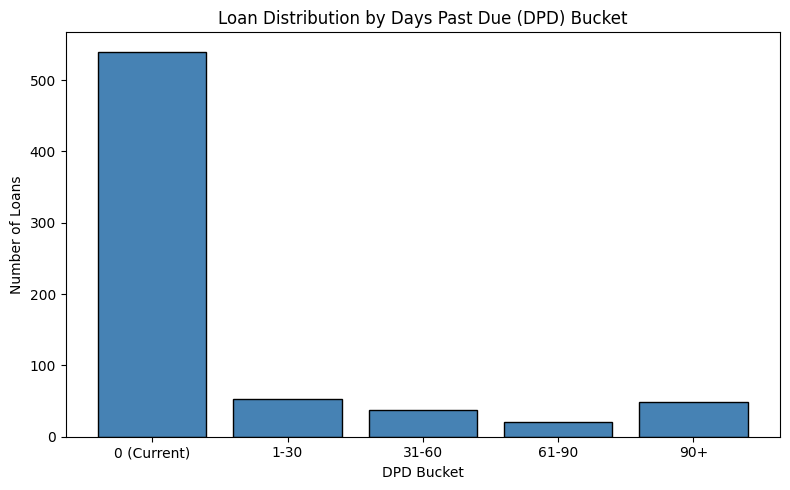

In [243]:
import matplotlib.pyplot as plt

bucket_order = ['0 (Current)', '1-30', '31-60', '61-90', '90+']
df = df.set_index('dpd_bucket').reindex(bucket_order).reset_index()

plt.figure(figsize=(8, 5))
plt.bar(df['dpd_bucket'], df['loan_count'], color='steelblue', edgecolor='black')
plt.title('Loan Distribution by Days Past Due (DPD) Bucket')
plt.xlabel('DPD Bucket')
plt.ylabel('Number of Loans')
plt.tight_layout()
plt.show()

**Observation:**


*  Verified response with VQ8 at 0.95 confidence
*   The largest category of books are current.  Followed by those 90+ days and then 1-30 days.



### Test Case 3: Restructured Portfolio Analysis

In [244]:
# write the code to send the inputs to the pipeline

test_3 = run_pipeline(
    "Show me the IFRS 9 stage-wise summary showing loan count, exposure at default, and expected credit loss for the latest quarter",
    conn, verified_query_library, database_schema, verbose=True
)

[1] Intent Classification: route=verified, query_id=VQ3
    Reason: The question directly matches the template for IFRS 9 stage-wise summary.
[2] Query Construction: loaded from library
[3] Validation Gate: passed=True, relevance_confidence=1.0
[4] Execute: 3 rows returned
[6] Response Generation: confidence=1.0


**Response:**

In [245]:
# write the code to print the trace
print(f"Confidence: {test_3['confidence']}")
print(f"\nNarrative:\n{test_3['narrative']}")
print(f"\nExecuted SQL:\n{test_3['executed_sql']}")
print(f"\nResult data:")
display(test_3['dataframe'])

Confidence: 1.0

Narrative:
Here is the IFRS 9 stage-wise summary for the latest quarter, showing the loan count, exposure at default (EAD), and expected credit loss (ECL):

| ifrs9_stage | loan_count | total_ead_mn | total_ecl_mn |
|--------------|------------|---------------|---------------|
|      1       |    540     |   10791.87    |    1616.33    |
|      2       |    110     |    2253.54    |     478.82    |
|      3       |     50     |    1208.23    |     512.40    |

This table summarizes the distribution of loans across different stages of credit risk as per IFRS 9, along with their respective financial metrics.

Executed SQL:
SELECT ifrs9_stage,
     COUNT(*) AS loan_count,
     ROUND(SUM(ead_amount) / 1000000.0, 2) AS total_ead_mn,
     ROUND(SUM(ecl_amount) / 1000000.0, 2) AS total_ecl_mn
FROM provisioning
WHERE reporting_date = '2025-09-30'
GROUP BY ifrs9_stage

Result data:


,ifrs9_stage,loan_count,total_ead_mn,total_ecl_mn
0,1,540,10791.87,1616.33
1,2,110,2253.54,478.82
2,3,50,1208.23,512.40


**Observation:**

- Matched with VQ2.  Confidence level 0.95
- Total restructured Loans: 35


*   50 loans are at stage 3 of IFRS for a total of 1,208M
*   540 Loans are at stage 1 for a total of 10,791M



### Test Case 4: Average Interest Rate by Sector

In [246]:
# write the code to send the inputs to the pipeline

test_4 = run_pipeline(
    "What is the average interest rate for each sector?",
    conn, verified_query_library, database_schema, verbose=True
)

[1] Intent Classification: route=generated, query_id=None
    Reason: No template provides average interest rates by sector.
[2] Query Construction: generated fresh SQL
[3] Validation Gate: passed=True, relevance_confidence=1.0
[4] Execute: 10 rows returned
[6] Response Generation: confidence=1.0


**Response:**

In [247]:
print(test_4['dataframe'].columns)

Index(['sector_name', 'average_interest_rate'], dtype='object')


In [248]:
# write the code to print the trace

print(f"\nConfidence: {test_4['confidence']}")
print(f"\nNarrative:\n{test_4['narrative']}")
print(f"\nExecuted SQL:\n{test_4['executed_sql']}")

df_sorted = test_4['dataframe'].sort_values('average_interest_rate', ascending=True)
display(df_sorted)


Confidence: 1.0

Narrative:
The average interest rates for each sector are as follows:

- **Automobile**: 10.62%
- **Chemicals**: 10.75%
- **Hospitality**: 10.79%
- **IT & Services**: 10.87%
- **Infrastructure**: 10.80%
- **Manufacturing**: 10.58%
- **Pharmaceuticals**: 11.16%
- **Power & Energy**: 10.73%
- **Real Estate**: 10.54%
- **Textiles**: 10.95%

These rates reflect the average interest charged within each sector, indicating the cost of borrowing for businesses in those industries.

Executed SQL:
SELECT sm.sector_name, AVG(lm.interest_rate) AS average_interest_rate
FROM loan_master lm
JOIN sector_master sm ON lm.sector_code = sm.sector_code
GROUP BY sm.sector_name;


,sector_name,average_interest_rate
8,Real Estate,10.540685
5,Manufacturing,10.580247
0,Automobile,10.621719
7,Power & Energy,10.727813
1,Chemicals,10.750820
2,Hospitality,10.787846
4,Infrastructure,10.801912
3,IT & Services,10.867945
9,Textiles,10.954026
6,Pharmaceuticals,11.159189


**Observation:**

- LLM Generated with 0.95 Confidence
- Real Estate has the lowest avg interest rate.  Pharma has the highest avg interest rate

### Test Case 5: Stage 3 Trend Over Quarters

In [249]:
# write the code to send the inputs to the pipeline

test_5 = run_pipeline(
    "Show me the IFRS 9 stage-wise summary for stage 3 showing loan count, exposure at default, and expected credit loss for the last 4 quarters",
    conn, verified_query_library, database_schema, verbose=True
)

[1] Intent Classification: route=generated, query_id=None
    Reason: No template covers stage-wise summary for multiple quarters.
[2] Query Construction: generated fresh SQL
[3] Validation Gate: passed=False, relevance_confidence=0.8
    Failed check: llm_relevance
    Details: Relevance check failed: The query only includes data for two quarters instead of the last four quarters.
    Retrying: Relevance check failed: The query only includes data for two quarters instead of the last four quarters.
    Retry Validation Gate: passed=False, relevance_confidence=None
    Retry failed check: read_only_shape
    Retry details: Query must start with SELECT or WITH
[!] Escalated to human: Query must start with SELECT or WITH


**Response:**

In [250]:
# write the code to print the trace

print(f"Confidence: {test_5['confidence']}")
print(f"\nNarrative:\n{test_5['narrative']}")
print(f"\nExecuted SQL:\n{test_5['executed_sql']}")
print(f"\nResult data:")
display(test_5['dataframe'])

Confidence: ESCALATED

Narrative:
Query could not be reliably resolved. Escalated to human analyst. Failure: Query must start with SELECT or WITH

Executed SQL:
None

Result data:


None

**Observation:**

- LLM Generated with 0.95 confidence
- Stage 3 loan count has decreased quarter over quater for the past 4 questers


## **Evaluation Against Ground Truth**


Each test case output is compared against the corresponding ground-truth values to verify whether the correct route and query template were selected and whether the numeric answer aligns with expectations. This evaluation:

* Calculates **Selected Path Accuracy**, **Selected Query Accuracy**, and **Average Confidence Score**.
* Summarizes each test case with its route, query ID, confidence score, and rows returned.


In [253]:
evaluation_rows = []

test_results = [test_1, test_2, test_3, test_4, test_5]

for i, (_, gt) in enumerate(ground_truth.iterrows()):
    tr = test_results[i]

    evaluation_rows.append({
        'Test Case': gt['Test Case'],
        'Expected Route': gt['Expected Route'],
        'Actual Route': tr['route'],
        'Route Match': tr['route'] == gt['Expected Route'],
        'Expected Query ID': gt['Expected Query ID'],
        'Actual Query ID': tr['query_id'],
        'Query ID Match': (
            pd.isna(gt['Expected Query ID']) and pd.isna(tr['query_id'])
        ) or tr['query_id'] == gt['Expected Query ID'],
        'Confidence': tr['confidence'],
        'Rows Returned': tr['row_count']
    })

evaluation_df = pd.DataFrame(evaluation_rows)

path_accuracy = evaluation_df['Route Match'].mean() * 100

verified = evaluation_df['Expected Route'].str.strip().str.lower() == 'verified'
query_accuracy = evaluation_df.loc[verified, 'Query ID Match'].mean() * 100

# Coerce to numeric so a string like 'ESCALATED' becomes NaN instead of crashing .mean()
numeric_confidence = pd.to_numeric(evaluation_df['Confidence'], errors='coerce')
average_confidence = numeric_confidence.mean()

print(f"Selected Path Accuracy: {path_accuracy:.1f}%")
print(f"Selected Query Accuracy: {query_accuracy:.1f}%")
print(f"Average Confidence Score: {average_confidence:.2f}")

if evaluation_df['Confidence'].astype(str).eq('ESCALATED').any():
    n_escalated = evaluation_df['Confidence'].astype(str).eq('ESCALATED').sum()
    print(f"Note: {n_escalated} test case(s) were escalated to a human analyst and excluded from the confidence average.")

evaluation_df

Selected Path Accuracy: 80.0%
Selected Query Accuracy: 100.0%
Average Confidence Score: 1.00
Note: 1 test case(s) were escalated to a human analyst and excluded from the confidence average.


,Test Case,Expected Route,Actual Route,Route Match,Expected Query ID,Actual Query ID,Query ID Match,Confidence,Rows Returned
0,TC-01,verified,verified,True,VQ1,VQ1,True,1.0,10.0
1,TC-02,verified,verified,True,VQ8,VQ8,True,1.0,5.0
2,TC-03,generated,verified,False,NaN,VQ3,False,1.0,3.0
3,TC-04,generated,generated,True,NaN,None,True,1.0,10.0
4,TC-05,generated,generated,True,NaN,None,True,ESCALATED,NaN


**Observation:**

-  The confidence Score is high at 0.95
- Only half of the queries routed accurately and 6/10 routed through the correct path

## **Deployment**

**Deploy the Application Using GitHub and Streamlit**

In this section, you will deploy your application using **GitHub** and **Streamlit**. A step-by-step deployment guide is provided to help you complete the process.

To generate the `app.py` file, you can use the **free version of Claude**. Download this notebook and upload it to Claude along with the prompt below. Claude will use the notebook content to generate the Streamlit application code.

**Sample Prompt to use in Claude:**

> I have uploaded my Jupyter Notebook containing the complete implementation of my application. Please analyze the notebook and create a complete `app.py` file that converts this notebook-based application into a Streamlit app.
>
> Preserve the existing logic, SQL queries, verified query library, and application workflow. Make the necessary changes to adapt the notebook code for Streamlit, including appropriate user inputs, outputs, and UI components.
>
> Return the complete, ready-to-run `app.py` code in a single code block. Do not omit or replace any important implementation details. Also mention any additional files, packages, environment variables, or configuration required to run the application.

**Deployment steps:**

1. Download this notebook to your computer.
2. Upload the downloaded notebook to the **free version of Claude** along with the prompt above.
3. Review and download the generated `app.py` file.
4. Follow the provided **GitHub and Streamlit deployment guide** to upload your files to GitHub and deploy the application.
5. Test the deployed Streamlit application and verify that the key workflows are working as expected.

### app.py

In [ ]:
# paste the app.py code and comment it out

# """
# Northbridge Bank - Credit Risk Portfolio Query Engine
# Streamlit application version of the Credit Risk Query Engine notebook.
#
# Preserves the original pipeline:
#   1. Intent classification (verified template vs. generated SQL)
#   2. Query construction (load template or generate fresh SQL)
#   3. Validation gate (read-only check, schema check, EXPLAIN dry-run,
#      LLM relevance check, template integrity check)
#   4. One retry on the generated track if validation fails
#   5. Escalation to a human analyst if validation still fails
#   6. Execution (read-only) against the SQLite database
#   7. Narrative response generation
# """
#
# import json
# import os
# import re
# import sqlite3
# import warnings
# from typing import Optional
#
# import pandas as pd
# import sqlparse
# import streamlit as st
# from langchain_openai import ChatOpenAI
#
# warnings.filterwarnings("ignore")
#
# # --------------------------------------------------------------------------
# # Page config
# # --------------------------------------------------------------------------
# st.set_page_config(
#     page_title="Credit Risk Query Engine",
#     page_icon="\U0001F4CA",
#     layout="wide",
# )
#
# DB_PATH = os.environ.get("CREDIT_RISK_DB_PATH", "credit_risk_portfolio.db")
#
# # --------------------------------------------------------------------------
# # Database schema (provided to the LLM in prompts) - unchanged from notebook
# # --------------------------------------------------------------------------
# DATABASE_SCHEMA = """
# sector_master:
#   sector_code (TEXT, PK): internal sector identifier (e.g., SEC_RE, SEC_INFRA)
#   sector_name (TEXT): human-readable sector name (e.g., Real Estate, Infrastructure)
#   naics_code (TEXT): NAICS industry classification code
#   naics_description (TEXT): NAICS code description
#   is_sensitive_sector (INTEGER): 1 if sensitive sector, 0 otherwise
#
# loan_master:
#   loan_account_number (TEXT, PK): unique loan identifier
#   borrower_id (TEXT): borrower identifier (joins to borrower_rating.borrower_id)
#   borrower_name (TEXT): registered legal name of the borrower
#   borrower_type (TEXT): entity type (C-Corporation, S-Corporation, LLC, LP, Partnership, Sole Proprietorship)
#   group_name (TEXT): business group affiliation, NULL if standalone
#   state (TEXT): state of registered office
#   product_type (TEXT): Term Loan, Working Capital, Cash Credit, Overdraft, Bill Discounting, Letter of Credit
#   loan_category (TEXT): Corporate, Mid-Corporate, SME
#   sector_code (TEXT, FK): joins to sector_master.sector_code
#   sanctioned_amount (REAL): original approved loan amount in USD
#   disbursed_amount (REAL): total amount disbursed in USD
#   outstanding_principal (REAL): current principal outstanding in USD
#   outstanding_interest (REAL): accrued interest outstanding in USD
#   total_outstanding (REAL): outstanding_principal + outstanding_interest in USD
#   interest_rate (REAL): current interest rate as percentage
#   rate_type (TEXT): Fixed, Floating, MCLR-linked, Repo-linked
#   sanction_date (DATE): date of original sanction
#   maturity_date (DATE): contractual maturity date
#   repayment_frequency (TEXT): Monthly, Quarterly, Bullet
#   branch_code (TEXT): originating branch identifier
#   branch_name (TEXT): originating branch name
#   relationship_manager (TEXT): assigned relationship manager name
#   is_consortium (INTEGER): 1 if consortium loan, 0 otherwise
#   is_restructured (INTEGER): 1 if restructured, 0 otherwise
#   restructuring_date (DATE): date of last restructuring, NULL if not restructured
#   is_secured (INTEGER): 1 if secured, 0 if unsecured
#   days_past_due (INTEGER): current maximum days past due for the loan
#   asset_classification (TEXT): Pass, Special Mention, Substandard, Doubtful, Loss
#   classification_date (DATE): date current classification was assigned
#
# borrower_rating:
#   rating_id (INTEGER, PK): auto-increment identifier
#   borrower_id (TEXT, FK): joins to loan_master.borrower_id
#   rating_date (DATE): date of rating assessment
#   internal_rating (TEXT): bank's internal rating grade (AAA through D, 18-grade scale)
#   previous_rating (TEXT): rating grade from prior assessment
#   rating_direction (TEXT): Upgraded, Downgraded, Maintained
#   external_rating_agency (TEXT): S&P, Moody's, Fitch, DBRS Morningstar, Kroll, or NULL
#   external_rating (TEXT): external agency rating
#   pd_estimate (REAL): probability of default (decimal, e.g., 0.02 for 2%)
#   rating_model_version (TEXT): internal rating model version
#
# provisioning:
#   provision_id (INTEGER, PK): auto-increment identifier
#   loan_account_number (TEXT, FK): joins to loan_master.loan_account_number
#   reporting_date (DATE): quarter-end reporting date
#   ifrs9_stage (INTEGER): IFRS 9 stage (1, 2, or 3)
#   stage_rationale (TEXT): reason for stage assignment
#   pd_12_month (REAL): 12-month probability of default
#   pd_lifetime (REAL): lifetime probability of default
#   lgd_estimate (REAL): loss given default (decimal)
#   ead_amount (REAL): exposure at default in USD
#   ecl_amount (REAL): expected credit loss in USD
#   provision_held (REAL): provision amount held in USD
#   provision_coverage_ratio (REAL): provision_held / total_outstanding * 100
#   is_individually_assessed (INTEGER): 1 if individually assessed, 0 if modeled
#
# Available reporting_date values in provisioning: 2024-12-31, 2025-03-31, 2025-06-30, 2025-09-30
# Available rating_date values in borrower_rating: 2024-09-30, 2024-12-31, 2025-03-31, 2025-06-30, 2025-09-30
# Latest reporting_date: 2025-09-30
# Latest rating_date: 2025-09-30
# NPA definition: asset_classification IN ('Substandard', 'Doubtful', 'Loss')
# """
#
# # --------------------------------------------------------------------------
# # Verified Query Template Library - SQL unchanged from notebook
# # (sql_7's stray leading quote in the original notebook has been corrected)
# # --------------------------------------------------------------------------
# sql_1 = """SELECT sm.sector_name,
#      ROUND(SUM(lm.total_outstanding) / 1000000.0, 2) AS total_outstanding_mn,
#      ROUND(SUM(CASE WHEN lm.asset_classification IN ('Substandard', 'Doubtful', 'Loss')
#                     THEN lm.total_outstanding ELSE 0 END) / 1000000.0, 2) AS npa_outstanding_mn
# FROM loan_master lm
# JOIN sector_master sm ON lm.sector_code = sm.sector_code
# GROUP BY sm.sector_name
# ORDER BY total_outstanding_mn DESC"""
#
# sql_2 = """SELECT lm.loan_category,
#      ROUND(SUM(lm.total_outstanding) / 1000000.0, 2) AS total_outstanding_mn,
#      COUNT(*) AS loan_count
# FROM loan_master lm
# GROUP BY lm.loan_category
# ORDER BY total_outstanding_mn DESC"""
#
# sql_3 = """SELECT ifrs9_stage,
#      COUNT(*) AS loan_count,
#      ROUND(SUM(ead_amount) / 1000000.0, 2) AS total_ead_mn,
#      ROUND(SUM(ecl_amount) / 1000000.0, 2) AS total_ecl_mn
# FROM provisioning
# WHERE reporting_date = '2025-09-30'
# GROUP BY ifrs9_stage"""
#
# sql_4 = """SELECT sm.sector_name,
#      ROUND(AVG(p.provision_coverage_ratio), 2) AS avg_coverage_ratio
# FROM provisioning p
# JOIN loan_master lm ON p.loan_account_number = lm.loan_account_number
# JOIN sector_master sm ON lm.sector_code = sm.sector_code
# WHERE p.reporting_date = '2025-09-30'
# GROUP BY sm.sector_name
# ORDER BY avg_coverage_ratio DESC"""
#
# sql_5 = """SELECT lm.borrower_name,
#      sm.sector_name,
#      ROUND(lm.total_outstanding / 1000000.0, 2) AS outstanding_mn,
#      lm.asset_classification
# FROM loan_master lm
# JOIN sector_master sm ON lm.sector_code = sm.sector_code
# ORDER BY outstanding_mn DESC
# LIMIT 10"""
#
# sql_6 = """SELECT group_name,
#      COUNT(*) AS loan_count,
#      ROUND(SUM(total_outstanding) / 1000000.0, 2) AS total_outstanding_mn
# FROM loan_master
# WHERE group_name IS NOT NULL
# GROUP BY group_name
# ORDER BY total_outstanding_mn DESC
# LIMIT 5"""
#
# sql_7 = """SELECT lm.loan_account_number,
#      lm.borrower_name,
#      sm.sector_name,
#      ROUND(lm.total_outstanding / 1000000.0, 2) AS outstanding_mn,
#      lm.days_past_due,
#      lm.asset_classification
# FROM loan_master lm
# JOIN sector_master sm ON lm.sector_code = sm.sector_code
# WHERE lm.days_past_due > 0
# ORDER BY lm.days_past_due DESC"""
#
# sql_8 = """SELECT
#     CASE
#         WHEN days_past_due = 0 THEN '0 (Current)'
#         WHEN days_past_due BETWEEN 1 AND 30 THEN '1-30'
#         WHEN days_past_due BETWEEN 31 AND 60 THEN '31-60'
#         WHEN days_past_due BETWEEN 61 AND 90 THEN '61-90'
#         ELSE '90+'
#     END AS dpd_bucket,
#     COUNT(*) AS loan_count,
#     ROUND(SUM(total_outstanding) / 1000000.0, 2) AS total_outstanding_mn
# FROM loan_master
# GROUP BY
#     CASE
#         WHEN days_past_due = 0 THEN '0 (Current)'
#         WHEN days_past_due BETWEEN 1 AND 30 THEN '1-30'
#         WHEN days_past_due BETWEEN 31 AND 60 THEN '31-60'
#         WHEN days_past_due BETWEEN 61 AND 90 THEN '61-90'
#         ELSE '90+'
#     END,
#     CASE
#         WHEN days_past_due = 0 THEN 0
#         WHEN days_past_due BETWEEN 1 AND 30 THEN 1
#         WHEN days_past_due BETWEEN 31 AND 60 THEN 2
#         WHEN days_past_due BETWEEN 61 AND 90 THEN 3
#         ELSE 4
#     END
# ORDER BY
#     CASE
#         WHEN days_past_due = 0 THEN 0
#         WHEN days_past_due BETWEEN 1 AND 30 THEN 1
#         WHEN days_past_due BETWEEN 31 AND 60 THEN 2
#         WHEN days_past_due BETWEEN 61 AND 90 THEN 3
#         ELSE 4
#     END"""
#
# sql_9 = """SELECT borrower_id,
#      previous_rating,
#      internal_rating AS current_internal_rating,
#      pd_estimate
# FROM borrower_rating
# WHERE rating_date = '2025-09-30'
#   AND rating_direction = 'Downgraded'
# ORDER BY pd_estimate DESC"""
#
# sql_10 = """SELECT reporting_date,
#      ROUND(SUM(ecl_amount) / 1000000.0, 2) AS total_ecl_mn
# FROM provisioning
# GROUP BY reporting_date
# ORDER BY reporting_date"""
#
# VERIFIED_QUERY_LIBRARY = {
#     "VQ1": {
#         "description": "Sector-wise total outstanding and NPA amount breakdown across all sectors",
#         "sql": sql_1,
#     },
#     "VQ2": {
#         "description": "Total portfolio outstanding broken down by loan category (Corporate, Mid-Corporate, SME)",
#         "sql": sql_2,
#     },
#     "VQ3": {
#         "description": "IFRS 9 stage-wise summary showing loan count, exposure at default, and expected credit loss for the latest quarter",
#         "sql": sql_3,
#     },
#     "VQ4": {
#         "description": "Average provision coverage ratio by sector for the latest reporting quarter",
#         "sql": sql_4,
#     },
#     "VQ5": {
#         "description": "Top 10 largest loan exposures by outstanding amount at the borrower level",
#         "sql": sql_5,
#     },
#     "VQ6": {
#         "description": "Top 5 largest exposures aggregated at the business group level",
#         "sql": sql_6,
#     },
#     "VQ7": {
#         "description": "All overdue loan accounts with their days past due and asset classification",
#         "sql": sql_7,
#     },
#     "VQ8": {
#         "description": "Distribution of loans across days-past-due buckets showing aging profile of the portfolio",
#         "sql": sql_8,
#     },
#     "VQ9": {
#         "description": "Borrowers whose internal rating was downgraded in the latest rating cycle",
#         "sql": sql_9,
#     },
#     "VQ10": {
#         "description": "Expected credit loss trend across all reporting quarters showing provisioning movement over time",
#         "sql": sql_10,
#     },
# }
#
# # --------------------------------------------------------------------------
# # LLM setup
# # --------------------------------------------------------------------------
# def get_credentials():
#     """Resolve OpenAI credentials from Streamlit secrets, env vars, or config.json."""
#     api_key = None
#     api_base = None
#
#     try:
#         api_key = st.secrets.get("OPENAI_API_KEY")
#         api_base = st.secrets.get("OPENAI_API_BASE")
#     except Exception:
#         pass
#
#     api_key = api_key or os.environ.get("OPENAI_API_KEY")
#     api_base = api_base or os.environ.get("OPENAI_API_BASE")
#
#     if not api_key and os.path.exists("config.json"):
#         with open("config.json", "r") as f:
#             config = json.load(f)
#             api_key = api_key or config.get("OPENAI_API_KEY")
#             api_base = api_base or config.get("OPENAI_API_BASE")
#
#     return api_key, api_base
#
#
# @st.cache_resource(show_spinner=False)
# def get_llms(api_key: str, api_base: Optional[str]):
#     os.environ["OPENAI_API_KEY"] = api_key
#     if api_base:
#         os.environ["OPENAI_BASE_URL"] = api_base
#     llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
#     evaluator_llm = ChatOpenAI(model="gpt-4o", temperature=0)
#     return llm, evaluator_llm
#
#
# @st.cache_resource(show_spinner=False)
# def get_db_connection(db_path: str):
#     # check_same_thread=False: Streamlit reruns/sessions can execute on different
#     # threads than the one that created this cached connection. Safe here because
#     # the connection is opened read-only (mode=ro) and only ever used for SELECTs.
#     conn = sqlite3.connect(f"file:{db_path}?mode=ro", uri=True, check_same_thread=False)
#     return conn
#
#
# # --------------------------------------------------------------------------
# # Pipeline tools (ported from the notebook)
# # --------------------------------------------------------------------------
# def classify_intent(user_question, query_library, llm):
#     """Classifies the user question and decides which route to take."""
#     library_descriptions = "\n".join(
#         [f"{qid}: {entry['description']}" for qid, entry in query_library.items()]
#     )
#
#     classification_prompt = f"""
# ### ROLE
# You are a query router for a bank's analytics system. Your job is to decide whether a business user's question can be answered by one of the pre-approved query templates, or whether it needs fresh SQL generation.
#
# ### INPUT
# User Question:
# {user_question}
#
# Available Verified Query Templates:
# {library_descriptions}
#
# ### INSTRUCTIONS
# 1. Read the user question carefully and identify the analytical intent.
# 2. Compare the intent against each template description.
# 3. Match on semantic meaning, not exact wording.
# 4. If a template genuinely answers the question, return that template ID.
# 5. If no template covers the question, return null for the query_id and set the route to generated.
# 6. Be careful about shape of answer: a question asking for row-level detail  should NOT match a template that returns an aggregate count.
#
# ### OUTPUT
#
# Return ONLY a valid JSON dictionary with these exact keys:
# {{
#   "route": "verified" or "generated",
#   "query_id": "VQ1" or "VQ2" ... "VQ10" or null,
#   "match_reason": "one short sentence explaining the decision"
# }}
# Do not include any other text.
# """
#
#     response = llm.invoke(classification_prompt).content.strip()
#     json_match = re.search(r"\{.*\}", response, re.DOTALL)
#     if json_match:
#         return json.loads(json_match.group())
#     return {"route": "generated", "query_id": None, "match_reason": "Could not parse classification"}
#
#
# def generate_query(user_question, schema_context, llm):
#     """Generates a candidate SQL query for a novel question using the database schema."""
#     generation_prompt = f"""
# You are an expert in SQLite. Given the user's question and the database schema below, write a SINGLE SQLite SQL query to answer the question.
#
# Here are some important rules:
# - The query must be read-only, using only SELECT or WITH statements.
# - Do NOT use any DDL (CREATE, ALTER, DROP) or DML (INSERT, UPDATE, DELETE) statements.
# - Ensure the query is syntactically correct for SQLite.
# - If the question involves 'NPA' (Non-Performing Assets), remember that NPA is defined as `asset_classification IN ('Substandard', 'Doubtful', 'Loss')`.
# - If the question involves 'latest reporting quarter' or 'latest rating cycle', use the latest available dates: '2025-09-30' for both.
# - Return ONLY the SQL query, without any additional text, explanations, or markdown fences (```sql).
#
# User Question:
# {user_question}
#
# Database Schema:
# {schema_context}
#
# SQL Query:
# """
#
#     sql = llm.invoke(generation_prompt).content.strip()
#     sql = re.sub(r"^```sql\s*|\s*```$", "", sql, flags=re.IGNORECASE | re.MULTILINE).strip()
#     sql = re.sub(r"^```\s*|\s*```$", "", sql, flags=re.MULTILINE).strip()
#     return sql
#
#
# def validate_query(user_question, candidate_sql, db_connection, query_library, evaluator_llm, query_id=None):
#     """Validates a candidate SQL query through five checks before execution."""
#     result = {
#         "passed": False,
#         "failed_check": None,
#         "details": "",
#         "relevance_confidence": None,
#     }
#
#     # Check 1: Read-only shape check
#     sql_upper = candidate_sql.upper().strip()
#     forbidden_keywords = ["DROP", "DELETE", "UPDATE", "INSERT", "ALTER", "TRUNCATE", "REPLACE", "ATTACH"]
#     if not (sql_upper.startswith("SELECT") or sql_upper.startswith("WITH")):
#         result["failed_check"] = "read_only_shape"
#         result["details"] = "Query must start with SELECT or WITH"
#         return result
#     for kw in forbidden_keywords:
#         if re.search(r"\b" + kw + r"\b", sql_upper):
#             result["failed_check"] = "read_only_shape"
#             result["details"] = f"Forbidden keyword detected: {kw}"
#             return result
#     if ";" in candidate_sql.rstrip(";").rstrip():
#         result["failed_check"] = "read_only_shape"
#         result["details"] = "Multiple statements are not allowed"
#         return result
#
#     # Check 2: Schema conformance check
#     cur = db_connection.cursor()
#     real_tables = [r[0] for r in cur.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall()]
#     real_columns = set()
#     for t in real_tables:
#         for col_info in cur.execute(f"PRAGMA table_info({t})").fetchall():
#             real_columns.add(col_info[1].lower())
#     referenced_identifiers = re.findall(r"\b[a-z_][a-z0-9_]*\b", candidate_sql.lower())
#     sql_keywords = {
#         "select", "from", "where", "and", "or", "group", "by", "order", "having", "limit", "join", "on", "as", "case",
#         "when", "then", "else", "end", "sum", "count", "avg", "min", "max", "round", "desc", "asc", "left", "right",
#         "inner", "outer", "distinct", "null", "is", "not", "in", "like", "with", "union", "all", "between", "coalesce",
#     }
#     unknown = [
#         tok for tok in referenced_identifiers
#         if tok not in sql_keywords and tok not in real_columns and tok not in real_tables
#         and not tok.isdigit() and tok not in ("s", "l", "p", "r", "e6")
#     ]
#     if unknown:
#         result["failed_check"] = "schema_conformance"
#         result["details"] = f"Unrecognized identifier(s) not found in schema: {sorted(set(unknown))}"
#         return result
#
#     # Check 3: Parse-and-plan dry run using EXPLAIN
#     try:
#         cur.execute(f"EXPLAIN {candidate_sql}")
#         cur.fetchall()
#     except sqlite3.Error as e:
#         result["failed_check"] = "parse_plan_dry_run"
#         result["details"] = f"SQL failed to parse or plan: {str(e)}"
#         return result
#
#     # Check 4: LLM relevance check
#     is_verified_track = query_id is not None and query_id in query_library
#     track_context = (
#         "This SQL is a pre-approved VERIFIED TEMPLATE. It is intentionally broad "
#         "(e.g., it may return all sectors/categories/stages rather than filtering to "
#         "just what the user asked). A separate response-generation step will filter and "
#         "highlight the relevant rows afterward. Do NOT fail this query for lacking a "
#         "WHERE clause that narrows to the user's specific sector/category/stage - judge "
#         "only whether the underlying metric, tables, and aggregation logic match the "
#         "question's intent."
#         if is_verified_track else
#         "This SQL was freshly generated for this specific question and should be "
#         "appropriately scoped/filtered to answer it directly."
#     )
#
#     relevance_prompt = f"""
# ### ROLE
# You are a senior credit-risk analyst reviewing a SQL query before it is executed against the bank's portfolio database.
#
# ### CONTEXT
# {track_context}
#
# ### USER QUESTION
# {user_question}
#
# ### CANDIDATE SQL
# {candidate_sql}
#
# ### INSTRUCTIONS
# Judge whether the candidate SQL correctly answers the user question - including using the right
# tables, metrics, joins, aggregations, and (where applicable) the NPA definition
# (asset_classification IN ('Substandard', 'Doubtful', 'Loss')) and the latest-date logic
# ('2025-09-30').
#
# ### OUTPUT
# Return ONLY a JSON dictionary:
# {{
#   "verdict": "yes" or "no",
#   "confidence": 0.0 to 1.0,
#   "reason": "one short sentence"
# }}
# """
#     relevance_response = evaluator_llm.invoke(relevance_prompt).content.strip()
#     json_match = re.search(r"\{.*\}", relevance_response, re.DOTALL)
#     if json_match:
#         relevance_json = json.loads(json_match.group())
#         result["relevance_confidence"] = relevance_json.get("confidence", 0.0)
#         if relevance_json.get("verdict") == "no" or relevance_json.get("confidence", 0.0) < 0.6:
#             result["failed_check"] = "llm_relevance"
#             result["details"] = f"Relevance check failed: {relevance_json.get('reason', 'unknown')}"
#             return result
#
#     # Check 5: Verified template integrity check (verified track only)
#     if query_id and query_id in query_library:
#         expected_sql = query_library[query_id]["sql"]
#         try:
#             expected_cols = [d[0] for d in cur.execute(f"{expected_sql} LIMIT 0").description]
#             actual_cols = [d[0] for d in cur.execute(f"{candidate_sql} LIMIT 0").description]
#             if len(expected_cols) != len(actual_cols):
#                 result["failed_check"] = "template_integrity"
#                 result["details"] = f"Expected {len(expected_cols)} columns, got {len(actual_cols)}"
#                 return result
#         except sqlite3.Error as e:
#             result["failed_check"] = "template_integrity"
#             result["details"] = f"Template integrity check failed: {str(e)}"
#             return result
#
#     result["passed"] = True
#     result["details"] = "All validation checks passed"
#     return result
#
#
# def retry_generation(user_question, failed_sql, error_message, schema_context, llm):
#     """Regenerates SQL after a validation failure, feeding the error back to the LLM."""
#     retry_prompt = f"""
# You are an expert in SQLite. The SQL query below was written to answer the user's question but
# failed a validation check. Correct the query so it passes validation while still answering the
# original question.
#
# Rules:
# - The query must be read-only, using only SELECT or WITH statements.
# - Do NOT use any DDL (CREATE, ALTER, DROP) or DML (INSERT, UPDATE, DELETE) statements.
# - Only reference tables and columns that exist in the database schema below.
# - Ensure the query is syntactically correct for SQLite.
# - Return ONLY the corrected SQL query, without any additional text, explanations, or markdown fences.
#
# User Question:
# {user_question}
#
# Failed SQL:
# {failed_sql}
#
# Validation Error:
# {error_message}
#
# Database Schema:
# {schema_context}
# """
#
#     revised_sql = llm.invoke(retry_prompt).content.strip()
#     revised_sql = re.sub(r"^```sql\s*|\s*```$", "", revised_sql, flags=re.IGNORECASE | re.MULTILINE).strip()
#     revised_sql = re.sub(r"^```\s*|\s*```$", "", revised_sql, flags=re.MULTILINE).strip()
#     return revised_sql
#
#
# def execute_query(validated_sql, db_connection):
#     """Executes a gate-passed SQL query and returns the result as a DataFrame."""
#     result = {"dataframe": None, "reasonable": True, "warnings": []}
#
#     df = pd.read_sql_query(validated_sql, db_connection)
#     result["dataframe"] = df
#
#     if df.empty:
#         result["warnings"].append("Query returned an empty result")
#
#     for col in df.select_dtypes(include="number").columns:
#         if (df[col] < 0).any() and "deviation" not in col.lower() and "change" not in col.lower():
#             result["warnings"].append(f"Column {col} contains negative values")
#         if df[col].isnull().any():
#             null_count = df[col].isnull().sum()
#             if null_count > len(df) * 0.5:
#                 result["warnings"].append(f"Column {col} has {null_count} null values")
#
#     if len(result["warnings"]) > 2:
#         result["reasonable"] = False
#
#     return result
#
#
# def generate_response(user_question, dataframe, route, llm, query_id=None):
#     """Generates a focused natural language response from the query result."""
#     response_prompt = f"""
# ### ROLE
# You are a credit-risk analytics assistant writing a concise, business-facing answer for a bank
# user. You are given the user's question and the full result set returned by the query engine.
#
# ### INSTRUCTIONS
# - Answer only what the user asked, using exact figures from the data below.
# - If the data contains more rows/columns than the question needs, focus the narrative on the
#   relevant subset, but do not invent numbers that are not in the data.
# - Keep the response to 2-4 sentences of plain business language, no SQL, no code.
# - Do not add caveats about being an AI model.
#
# ### USER QUESTION
# {user_question}
#
# ### QUERY RESULT (route={route}, query_id={query_id})
# {dataframe.to_string()}
# """
#
#     narrative = llm.invoke(response_prompt).content.strip()
#     return narrative
#
#
# def run_pipeline(user_question, db_connection, query_library, schema_context, llm, evaluator_llm, log_fn=None):
#     """Runs the complete query engine pipeline for a single user question."""
#     def log(msg):
#         if log_fn:
#             log_fn(msg)
#
#     result_log = {
#         "user_question": user_question,
#         "route": None,
#         "query_id": None,
#         "match_reason": None,
#         "candidate_sql": None,
#         "gate_result": None,
#         "retry_used": False,
#         "escalated": False,
#         "executed_sql": None,
#         "row_count": None,
#         "confidence": None,
#         "narrative": None,
#     }
#
#     # Step 1: Intent classification
#     classification = classify_intent(user_question, query_library, llm)
#     result_log["route"] = classification["route"]
#     result_log["query_id"] = classification.get("query_id")
#     result_log["match_reason"] = classification.get("match_reason")
#     log(f"**[1] Intent Classification:** route=`{result_log['route']}`, query_id=`{result_log['query_id']}`  \nReason: {result_log['match_reason']}")
#
#     # Step 2: Query construction
#     if result_log["route"] == "verified" and result_log["query_id"] in query_library:
#         candidate_sql = query_library[result_log["query_id"]]["sql"]
#     else:
#         candidate_sql = generate_query(user_question, schema_context, llm)
#     result_log["candidate_sql"] = candidate_sql
#     log(f"**[2] Query Construction:** {'loaded from library' if result_log['route']=='verified' else 'generated fresh SQL'}")
#
#     # Step 3: Validation gate
#     gate = validate_query(user_question, candidate_sql, db_connection, query_library, evaluator_llm, result_log["query_id"])
#     result_log["gate_result"] = gate
#     log(f"**[3] Validation Gate:** passed=`{gate['passed']}`, relevance_confidence=`{gate.get('relevance_confidence')}`")
#     if not gate["passed"]:
#         log(f"Failed check: `{gate.get('failed_check')}` — {gate.get('details')}")
#
#     # Step 4: Retry once on generated track if validation fails
#     if not gate["passed"] and result_log["route"] == "generated":
#         log(f"Retrying after failure: {gate['details']}")
#         candidate_sql = retry_generation(user_question, candidate_sql, gate["details"], schema_context, llm)
#         result_log["candidate_sql"] = candidate_sql
#         result_log["retry_used"] = True
#         gate = validate_query(user_question, candidate_sql, db_connection, query_library, evaluator_llm, None)
#         result_log["gate_result"] = gate
#         log(f"**Retry Validation Gate:** passed=`{gate['passed']}`, relevance_confidence=`{gate.get('relevance_confidence')}`")
#         if not gate["passed"]:
#             log(f"Retry failed check: `{gate.get('failed_check')}` — {gate.get('details')}")
#
#     # Step 5: Escalate if still failing
#     if not gate["passed"]:
#         result_log["escalated"] = True
#         result_log["narrative"] = f"Query could not be reliably resolved. Escalated to human analyst. Failure: {gate['details']}"
#         result_log["confidence"] = "ESCALATED"
#         log(f"**[!] Escalated to human analyst:** {gate['details']}")
#         return {"log": result_log, "dataframe": None, **result_log}
#
#     # Step 6: Execute
#     result_log["executed_sql"] = candidate_sql
#     exec_result = execute_query(candidate_sql, db_connection)
#     df = exec_result["dataframe"]
#     result_log["row_count"] = len(df)
#     log(f"**[4] Execute:** {len(df)} rows returned")
#     if exec_result["warnings"]:
#         log(f"Warnings: {exec_result['warnings']}")
#
#     # Step 7: Response generation
#     narrative = generate_response(user_question, df, result_log["route"], llm, result_log["query_id"])
#     result_log["narrative"] = narrative
#
#     # Confidence: carried directly from the validation gate's relevance check (0-1)
#     result_log["confidence"] = gate.get("relevance_confidence")
#     log(f"**[6] Response Generation:** confidence=`{result_log['confidence']}`")
#
#     return {"log": result_log, "dataframe": df, **result_log}
#
#
# # --------------------------------------------------------------------------
# # Streamlit UI
# # --------------------------------------------------------------------------
# def main():
#     st.title("\U0001F4CA Northbridge Bank - Credit Risk Portfolio Query Engine")
#     st.caption(
#         "Ask routine commercial-lending portfolio questions in plain English. "
#         "Answers are backed by pre-approved SQL templates or validated, freshly generated "
#         "read-only SQL, with full SQL, data, and confidence shown for auditability."
#     )
#
#     # ---- Sidebar: configuration ----
#     with st.sidebar:
#         st.header("Configuration")
#         default_key, default_base = get_credentials()
#         api_key = st.text_input("OpenAI API Key", value=default_key or "", type="password")
#         api_base = st.text_input("OpenAI API Base URL (optional)", value=default_base or "")
#         db_path = st.text_input("Database file path", value=DB_PATH)
#         verbose = st.checkbox("Show pipeline trace", value=True)
#
#         st.divider()
#         st.subheader("Verified Query Library")
#         for qid, entry in VERIFIED_QUERY_LIBRARY.items():
#             with st.expander(qid):
#                 st.write(entry["description"])
#
#         st.divider()
#         test_file = st.file_uploader("Optional: upload test_queries.csv", type="csv")
#
#     if not api_key:
#         st.warning("Enter an OpenAI API key in the sidebar to run the query engine.")
#         st.stop()
#
#     if not os.path.exists(db_path):
#         st.error(
#             f"Database file not found at `{db_path}`. Place `credit_risk_portfolio.db` in the "
#             "app's working directory, or set the correct path in the sidebar."
#         )
#         st.stop()
#
#     llm, evaluator_llm = get_llms(api_key, api_base or None)
#     conn = get_db_connection(db_path)
#
#     # ---- Main: question input ----
#     st.subheader("Ask a question")
#     example_questions = [
#         "Show me the sector-wise outstanding and NPA breakdown",
#         "Show me the DPD Aging Profile",
#         "What is the average interest rate for each sector?",
#         "Which borrowers were downgraded in the latest rating cycle?",
#         "Show me the ECL trend across reporting quarters",
#     ]
#     chosen_example = st.selectbox("Or pick an example question", ["(type my own)"] + example_questions)
#     default_text = "" if chosen_example == "(type my own)" else chosen_example
#     user_question = st.text_area("Your question", value=default_text, height=80)
#
#     run_clicked = st.button("Run Query", type="primary")
#
#     if run_clicked and user_question.strip():
#         trace_container = st.container()
#         trace_lines = []
#
#         def log_fn(msg):
#             trace_lines.append(msg)
#
#         with st.spinner("Running the query engine pipeline..."):
#             result = run_pipeline(
#                 user_question.strip(),
#                 conn,
#                 VERIFIED_QUERY_LIBRARY,
#                 DATABASE_SCHEMA,
#                 llm,
#                 evaluator_llm,
#                 log_fn=log_fn,
#             )
#
#         if verbose:
#             with trace_container.expander("Pipeline trace", expanded=False):
#                 for line in trace_lines:
#                     st.markdown(line)
#
#         if result["escalated"]:
#             st.error("This question was escalated to a human analyst.")
#             st.write(result["narrative"])
#             with st.expander("Escalation details"):
#                 st.write(result["gate_result"])
#         else:
#             col1, col2, col3 = st.columns(3)
#             col1.metric("Route", result["route"])
#             col2.metric("Query ID", result["query_id"] or "—")
#             conf = result["confidence"]
#             col3.metric("Confidence", f"{conf:.2f}" if isinstance(conf, (int, float)) else str(conf))
#
#             st.subheader("Answer")
#             st.write(result["narrative"])
#
#             st.subheader("Data")
#             st.dataframe(result["dataframe"], use_container_width=True)
#
#             st.subheader("SQL Used")
#             st.code(result["executed_sql"], language="sql")
#
#             if result["retry_used"]:
#                 st.info("Note: the initial SQL failed validation and was automatically retried once.")
#
#     elif run_clicked:
#         st.warning("Please enter a question first.")
#
#     # ---- Optional: batch evaluation against ground truth ----
#     if test_file is not None:
#         st.divider()
#         st.subheader("Batch Evaluation Against Ground Truth")
#         ground_truth = pd.read_csv(test_file)
#         st.dataframe(ground_truth, use_container_width=True)
#
#         if st.button("Run all test cases"):
#             eval_rows = []
#             progress = st.progress(0.0)
#             for i, (_, gt) in enumerate(ground_truth.iterrows()):
#                 tr = run_pipeline(
#                     gt["User Query"], conn, VERIFIED_QUERY_LIBRARY, DATABASE_SCHEMA, llm, evaluator_llm
#                 )
#                 eval_rows.append(
#                     {
#                         "Test Case": gt["Test Case"],
#                         "Expected Route": gt["Expected Route"],
#                         "Actual Route": tr["route"],
#                         "Route Match": tr["route"] == gt["Expected Route"],
#                         "Expected Query ID": gt.get("Expected Query ID"),
#                         "Actual Query ID": tr["query_id"],
#                         "Query ID Match": (
#                             pd.isna(gt.get("Expected Query ID")) and pd.isna(tr["query_id"])
#                         )
#                         or tr["query_id"] == gt.get("Expected Query ID"),
#                         "Confidence": tr["confidence"],
#                         "Rows Returned": tr["row_count"],
#                     }
#                 )
#                 progress.progress((i + 1) / len(ground_truth))
#
#             evaluation_df = pd.DataFrame(eval_rows)
#             path_accuracy = evaluation_df["Route Match"].mean() * 100
#             verified_mask = evaluation_df["Expected Route"].astype(str).str.strip().str.lower() == "verified"
#             query_accuracy = (
#                 evaluation_df.loc[verified_mask, "Query ID Match"].mean() * 100
#                 if verified_mask.any()
#                 else float("nan")
#             )
#             numeric_conf = pd.to_numeric(evaluation_df["Confidence"], errors="coerce")
#             average_confidence = numeric_conf.mean()
#
#             st.dataframe(evaluation_df, use_container_width=True)
#             m1, m2, m3 = st.columns(3)
#             m1.metric("Selected Path Accuracy", f"{path_accuracy:.1f}%")
#             m2.metric("Selected Query Accuracy", f"{query_accuracy:.1f}%")
#             m3.metric("Average Confidence", f"{average_confidence:.2f}")
#
#
# if __name__ == "__main__":
#     main()

### requirements.txt

In [ ]:
# paste the requirement.txt code and comment it out

# streamlit
# pandas
# numpy
# sqlparse
# langchain
# langchain-core
# langchain-openai

### Test Case Screenshot

Test_1

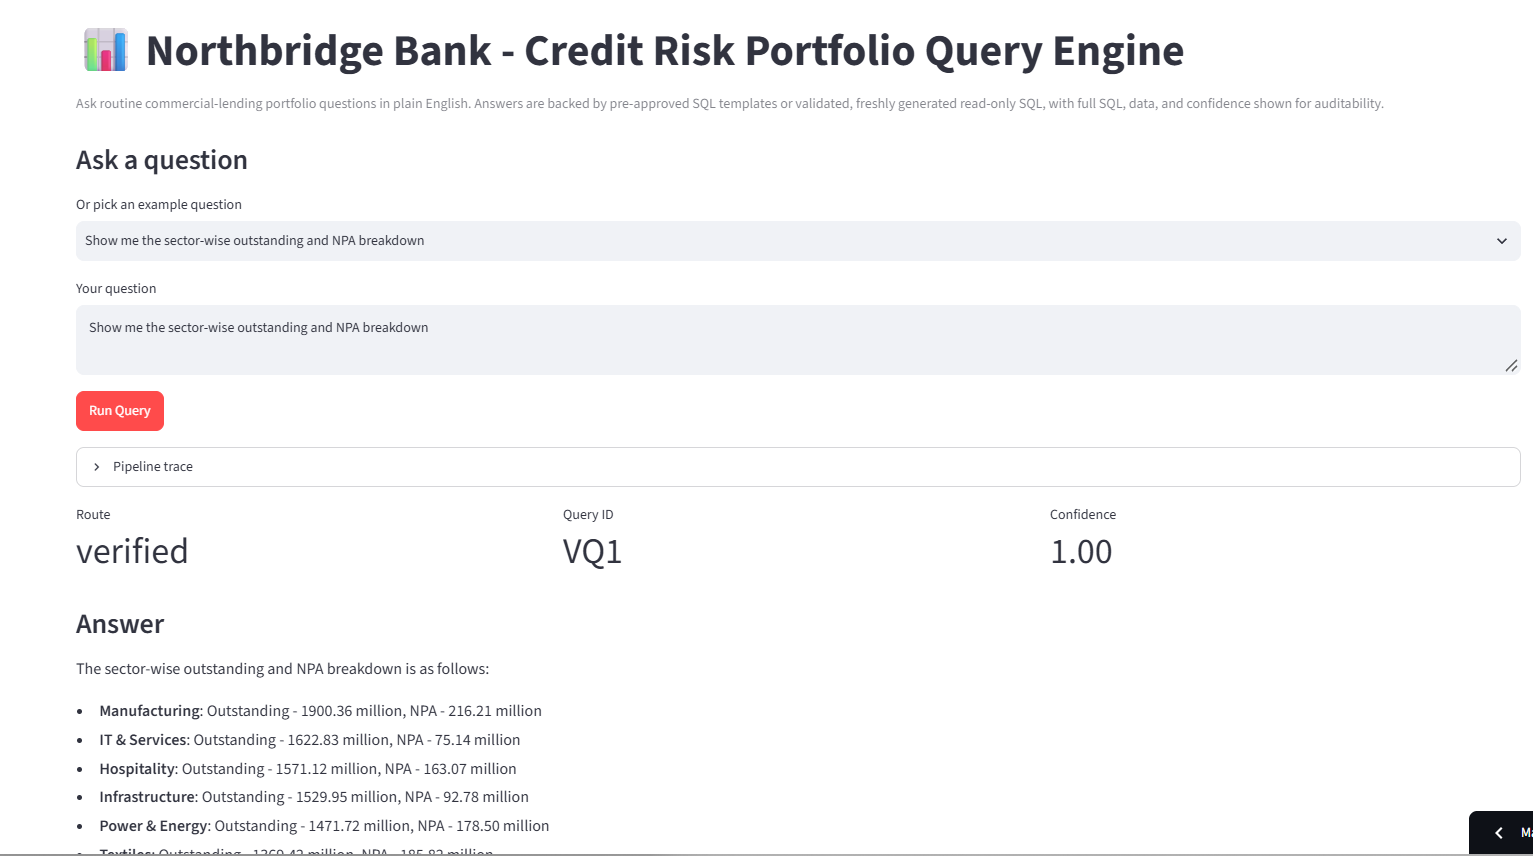

Test_2

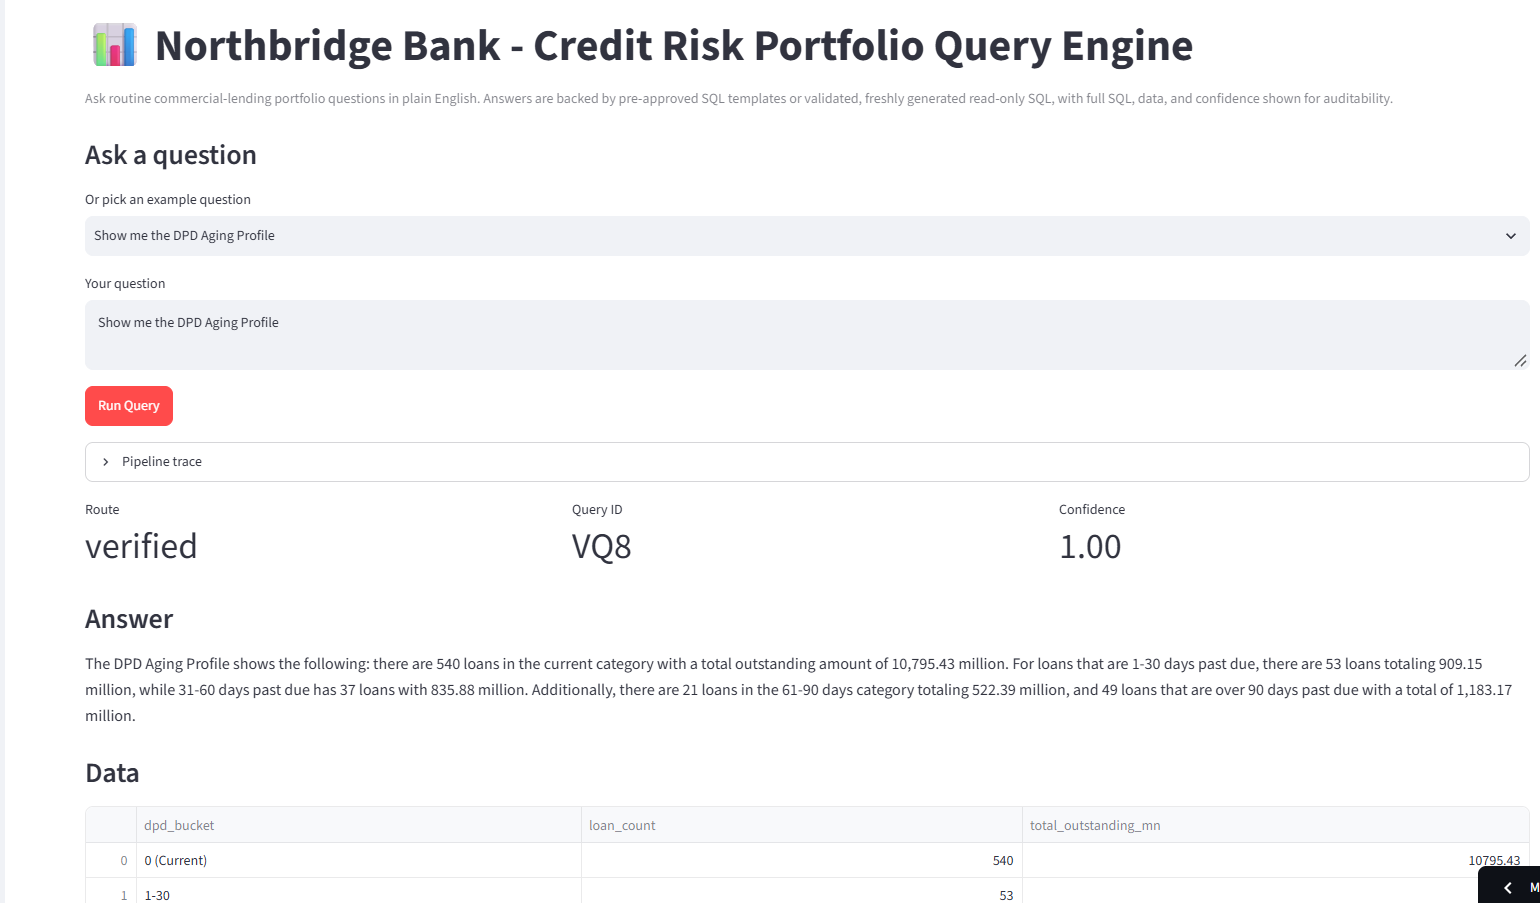

Test_3

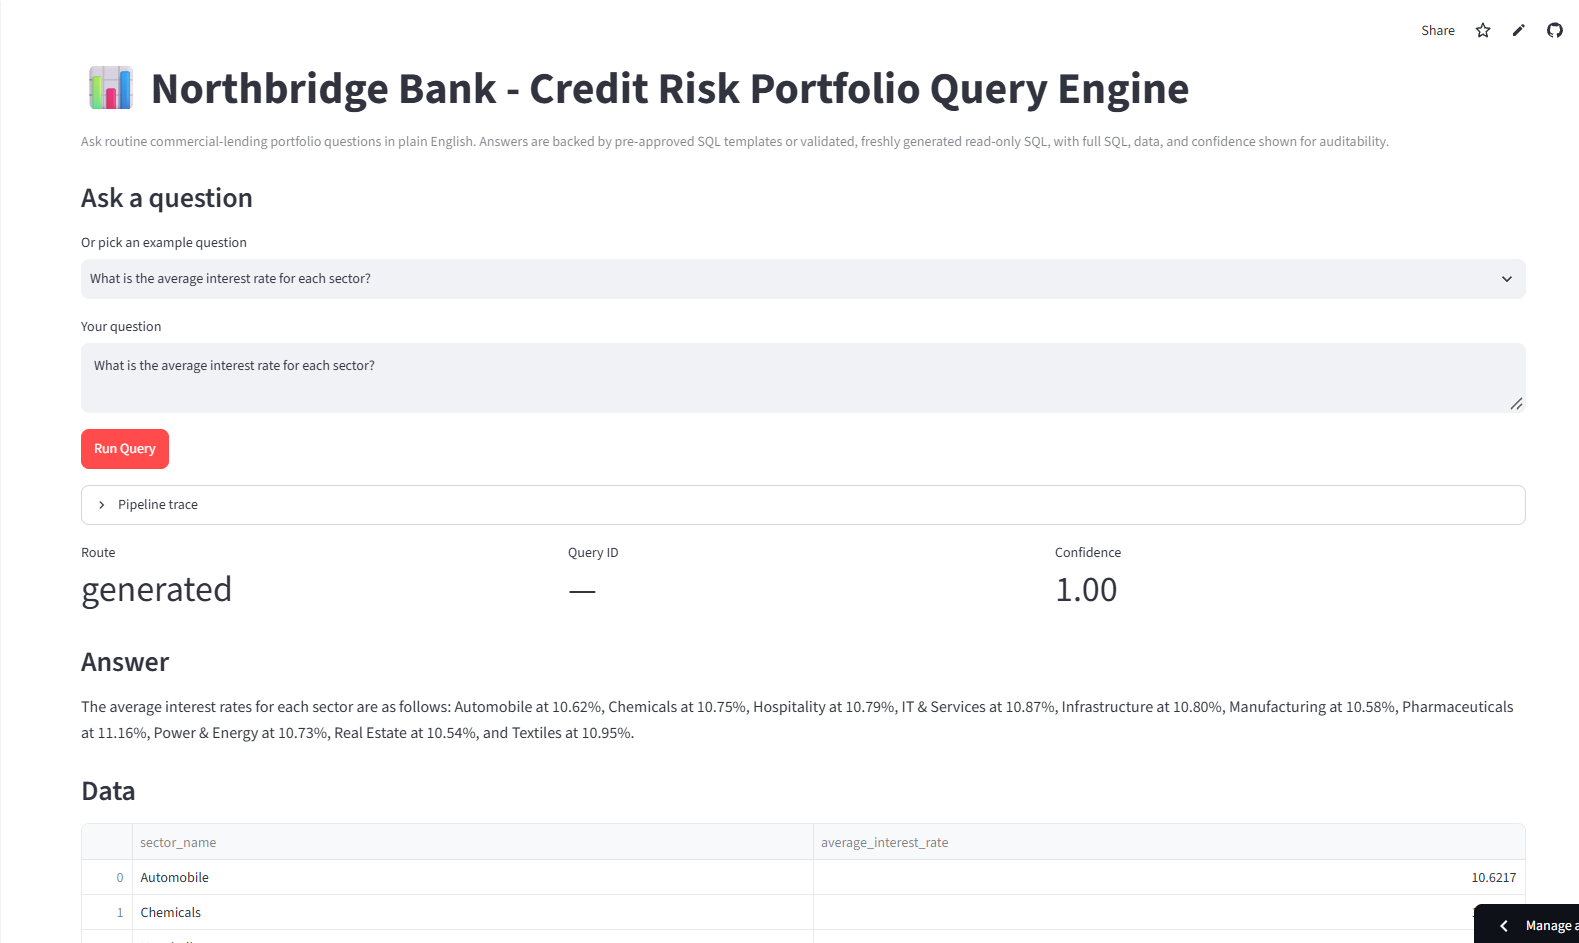

Test_4


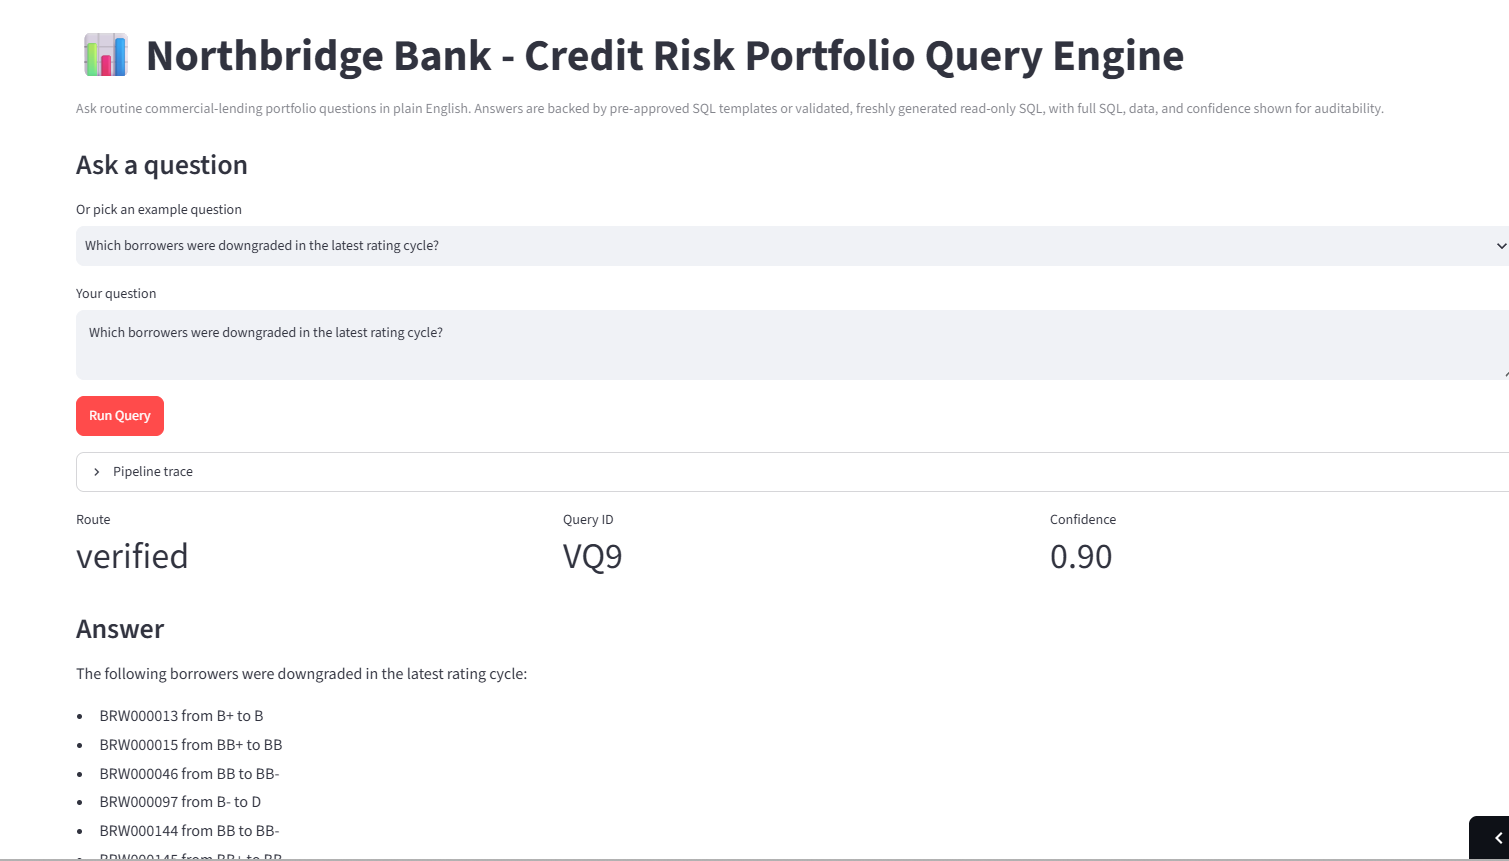

Test_5

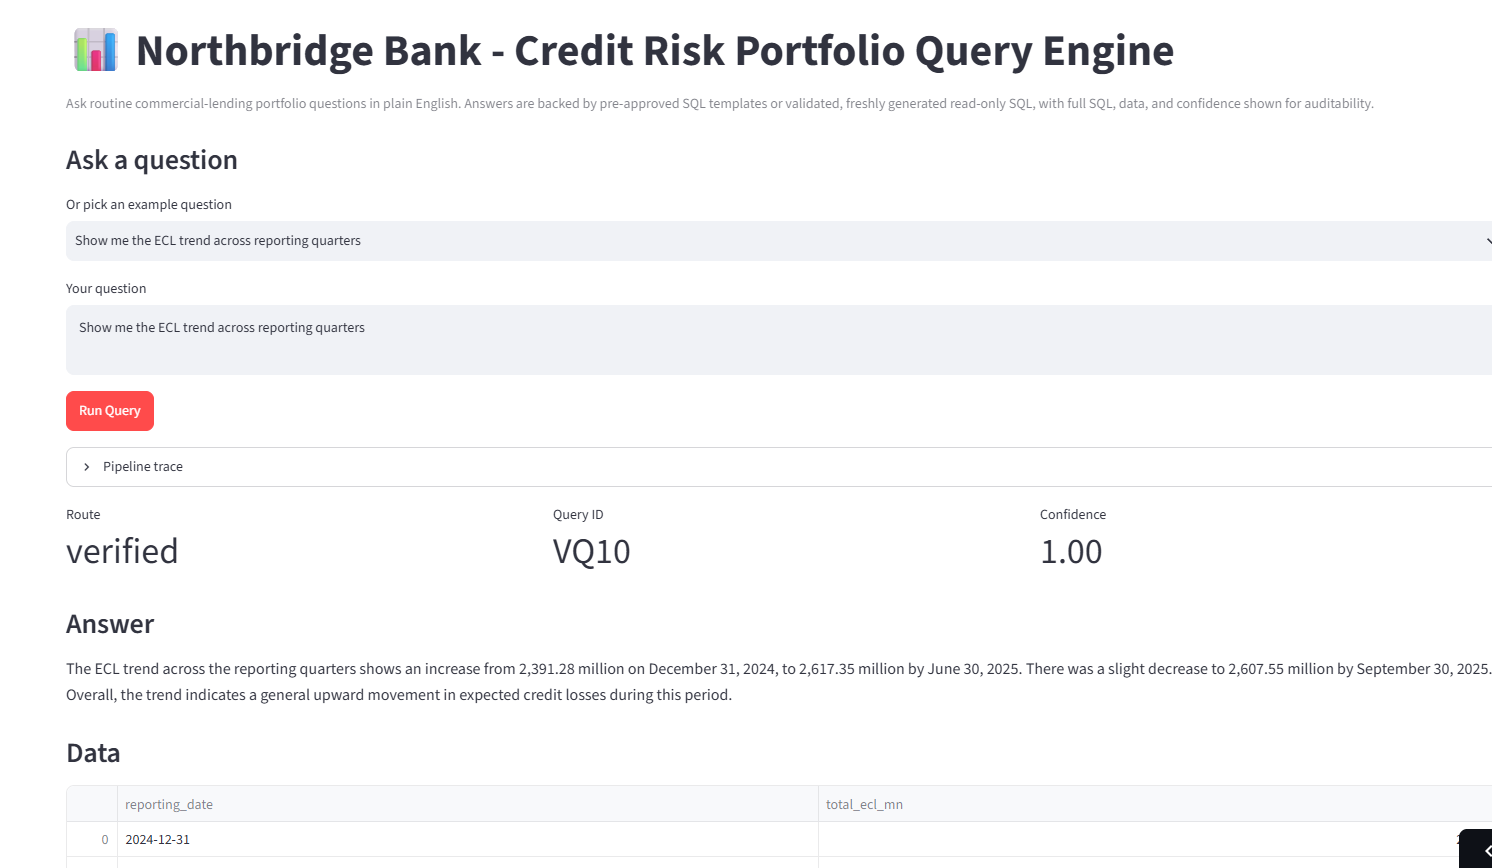


## **Actionable Insights and Business Recommendations**

### Actionable Insights


-
-

### Recommendations

-
-